# based on PMOD retrieval

http://localhost:8888/lab/workspaces/surfrad_mfrsr_raw2netcdf/tree/projects/cmpaign_2025_PMOD/calibrate_cosine.ipynb

# Read the sol file such that it can replace the cucf calibrations

## read the sol file

In [27]:
import atmPy.data_archives.NOAA_ESRL_GMD_GRAD.cal_facility.lab as atmcal

In [158]:
reload(atmcal)

<module 'atmPy.data_archives.NOAA_ESRL_GMD_GRAD.cal_facility.lab' from '/Users/htelg/prog/atm-py/atmPy/data_archives/NOAA_ESRL_GMD_GRAD/cal_facility/lab.py'>

In [159]:
p2f = pl.Path('/Volumes/grad/Calibration_facilities/cucf/NOAA_GRAD_VisMFRSRs/V0669/Reported/V0669_20151114.sol')
sol = atmcal.read_factory_cal_sol(p2f)

In [160]:
sol

<xarray.Dataset> Size: 22kB
Dimensions:       (angle: 181, channel: 6)
Coordinates:
  * angle         (angle) float64 1kB -90.0 -89.0 -88.0 -87.0 ... 88.0 89.0 90.0
  * channel       (channel) int64 48B 415 500 1625 670 870 940
Data variables:
    wavelength    (channel) float64 48B 413.6 500.0 1.623e+03 672.8 868.0 937.3
    broadband_NS  (angle) float64 1kB 1.95 0.2204 0.4049 ... 0.5467 0.4408 1.95
    broadband_EW  (angle) float64 1kB 1.95 0.4515 0.555 ... 0.6863 0.6094 1.95
    spectral_EW   (channel, angle) float64 9kB 1.95 0.6048 0.6779 ... 0.478 1.95
    spectral_NS   (channel, angle) float64 9kB 1.95 0.4929 ... 0.5579 1.95
Attributes:
    source_file:  /Volumes/grad/Calibration_facilities/cucf/NOAA_GRAD_VisMFRS...

## compare to a spr file

In [161]:
p2f = pl.Path('/Volumes/grad/Calibration_facilities/cucf/NOAA_GRAD_VisMFRSRs/V0660/Reported/V0660_20240125.spr')
spr = atmcal.read_mfrsr_cal(p2f)

In [162]:
spr

<xarray.Dataset> Size: 396kB
Dimensions:         (channel: 6, stats: 4, wavelength: 3957)
Coordinates:
  * channel         (channel) int64 48B 415 500 1625 670 870 940
  * stats           (stats) object 32B 'CENT' 'FWHM' 'CENT_UNCERT' 'FWHM_UNCERT'
  * wavelength      (wavelength) float32 16kB 390.0 390.1 ... 1.655e+03
Data variables:
    statistics      (channel, stats) float64 192B 414.9 10.64 ... 0.2413 1.347
    responds        (wavelength, channel) float64 190kB 0.000614 nan ... nan nan
    responds_error  (wavelength, channel) float64 190kB 0.000614 nan ... nan nan
Attributes:
    header:        Header:\nSPECTRAL RESPONSE TEST:\n\nInstrument Data:\nSeri...
    product_name:  mfr_grad_spectral_calibration
    source_file:   /Volumes/grad/Calibration_facilities/cucf/NOAA_GRAD_VisMFR...

In [166]:
sol.wavelength

<xarray.DataArray 'wavelength' (channel: 6)> Size: 48B
array([ 413.6 ,  500.  , 1623.47,  672.8 ,  868.  ,  937.3 ])
Coordinates:
  * channel  (channel) int64 48B 415 500 1625 670 870 940
Attributes:
    unit:       nm
    long_name:  Channel center wavelength.

## comparre to a cos file

In [163]:
p2f = pl.Path('/Volumes/grad/Calibration_facilities/cucf/NOAA_GRAD_VisMFRSRs/V0660/Reported/V0660_20240208.cos')
cos = atmcal.read_mfrsr_cal_cos(p2f)

In [164]:
cos

<xarray.Dataset> Size: 22kB
Dimensions:       (angle: 179, channel: 6)
Coordinates:
  * angle         (angle) int64 1kB -89 -88 -87 -86 -85 -84 ... 85 86 87 88 89
  * channel       (channel) int64 48B 415 500 1625 670 870 940
Data variables:
    broadband_NS  (angle) float64 1kB 0.2938 0.4307 0.5566 ... 0.4989 0.4402
    spectral_NS   (angle, channel) float64 9kB 0.4076 0.4158 ... 0.474 0.4834
    broadband_EW  (angle) float64 1kB 0.4755 0.5673 0.6616 ... 0.4211 0.3683
    spectral_EW   (angle, channel) float64 9kB 0.5732 0.5698 ... 0.3494 0.3539
Attributes:
    header:        Header:\nAngular_Response_Calibration\nMeasurement_Purpose...
    product_name:  mfr_grad_cosine_responds
    source_file:   /Volumes/grad/Calibration_facilities/cucf/NOAA_GRAD_VisMFR...

In [149]:
sol

<xarray.Dataset> Size: 22kB
Dimensions:       (angle: 181, channel: 6)
Coordinates:
  * angle         (angle) float64 1kB -90.0 -89.0 -88.0 -87.0 ... 88.0 89.0 90.0
  * channel       (channel) int64 48B 415 500 1625 670 870 940
Data variables:
    wavelength    (channel) float64 48B 413.6 500.0 1.623e+03 672.8 868.0 937.3
    broadband_NS  (angle) float64 1kB 1.95 0.2204 0.4049 ... 0.5467 0.4408 1.95
    broadband_EW  (angle) float64 1kB 1.95 0.4515 0.555 ... 0.6863 0.6094 1.95
    spectral_EW   (channel, angle) float64 9kB 1.95 0.6048 0.6779 ... 0.478 1.95
    spectral_NS   (channel, angle) float64 9kB 1.95 0.4929 ... 0.5579 1.95
Attributes:
    source_file:  /Volumes/grad/Calibration_facilities/cucf/NOAA_GRAD_VisMFRS...

In [153]:
sol.source_file

True

# Calibrate files

In [1]:
import atmPy.data_archives.NOAA_ESRL_GMD_GRAD.cal_facility.lab as atmcal

In [2]:
import surfradpy.scripts.surfrad_mfrsr_cosinecalibration as srfccc
import productomator.worker as prowork

In [3]:
# colrenames = {'4155': np.int64(1625), '500': np.int64(500), '1625': np.int64(1625), '670': np.int64(670), '870': np.int64(870), '940': np.int64(940)}

# if np.any(np.array([abs(float(k)-v) for k,v in colrenames.items()]) > 20):
#     txt = f'''I believe there is a parsing error in the channels. Channels are parsed with Current matching table:
#     {colrenames}
#     '''
#     raise ValueError(txt)

In [48]:
reload(srfccc)
reload(srfccc.prolab)
reload(srfccc.srfcc)
reload(srfccc.srfcc.pm)
reload(srfccc.srfcc.pm.worker)
reload(srfccc.srfcc.atmspc)
reload(srfccc.srfcc.atmspc.atmcal)


<module 'atmPy.data_archives.NOAA_ESRL_GMD_GRAD.cal_facility.lab' from '/Users/htelg/prog/atm-py/atmPy/data_archives/NOAA_ESRL_GMD_GRAD/cal_facility/lab.py'>

In [49]:
srfccc.srfcc.atmspc.atmcal.read_factory_cal_sol

<function atmPy.data_archives.NOAA_ESRL_GMD_GRAD.cal_facility.lab.read_factory_cal_sol(path: str | pathlib._local.Path) -> xarray.core.dataset.Dataset>

In [51]:
ci = srfccc.run(
    prefix='Volumes',
    log_folder=None,#'/home/grad/htelg/.processlogs/',
    start=None,
    end=None,
    noofdays=60,
    test=False,
    verbose=True,
    raise_errors=True
)

start surfrad_mfrsr_cosinecalibration
start time: 2026-04-21 15:32:11.785990
bnd
-----
Get all files in /Volumes/grad/Inst/MFR/SURFRAD/bnd/mfrsr/raw.netcdf/v0.3 with "files_between" function and start: 2026-02-20 15:32:11.786041, end: 2026-04-21 15:32:11.786041 and glob pattern: *.nc


bnd workplan.shape: (53, 2)


Using cosine calibration file: /Volumes/grad/Calibration_facilities/cucf/NOAA_GRAD_VisMFRSRs/V0672/Reported/V0672_20160609.cos
Using spectral calibration file: /Volumes/grad/Calibration_facilities/cucf/NOAA_GRAD_VisMFRSRs/V0672/Reported/V0672_20160605.spr


original columns: ['apparent_zenith', 'zenith', 'apparent_elevation', 'elevation', 'azimuth', 'equation_of_time']


.

...

original columns: ['apparent_zenith', 'zenith', 'apparent_elevation', 'elevation', 'azimuth', 'equation_of_time']


.

Using cosine calibration file: /Volumes/grad/Calibration_facilities/cucf/NOAA_GRAD_VisMFRSRs/V0650/Reported/V0650_20160531.cos
Using spectral calibration file: /Volumes/grad/Calibration_facilities/cucf/NOAA_GRAD_VisMFRSRs/V0650/Reported/V0650_20160728.spr


original columns: ['apparent_zenith', 'zenith', 'apparent_elevation', 'elevation', 'azimuth', 'equation_of_time']


.number of cleanes: 375
number of errors: 0
number of warnings: 0
time finished: 2026-04-21 15:49:54.774656
total processing time: 0.29527462944444444 hours
No log file specified, skipping logging.


In [21]:
ci.verbose

True

In [ ]:
pd.rea/Volumes/grad/Calibration_facilities/cucf/NOAA_GRAD_VisMFRSRs/V0672/Reported/V0672_20160605.spr

In [ ]:
'/Volumes/grad/Inst/MFR/SURFRAD/bnd/mfrsr/cosine_corrected/v0.1/2026/bnd_mfrsr_cosinecorrected_20260411.nc'

In [ ]:
Angle	Cos	NS_Corr_Thermopile	NS_Corr_415nm	NS_Corr_500nm	NS_Corr_1625nm	NS_Corr_670nm	NS_Corr_870nm	NS_Corr_940nm	NS_RelStdDv_Thermopile	NS_RelStdDv_415nm	NS_RelStdDv_500nm	NS_RelStdDv_1625nm	NS_RelStdDv_670nm	NS_RelStdDv_870nm	NS_RelStdDv_940nm		

In [1]:
import productomator as pm

In [2]:
import sol_parser

In [3]:
plt.rcParams['figure.dpi'] = 200

In [4]:
reload(pm)
reload(pm.worker)

<module 'productomator.worker' from '/Users/htelg/prog/productomator/productomator/worker.py'>

# This issue, when i apply my cosine it looks different

In [18]:
import productomator as pm

In [19]:
import atmPy.radiation.instrumentation.spectral as atmspc

In [20]:
reload(pm)
reload(pm.worker)

<module 'productomator.worker' from '/Users/htelg/prog/productomator/productomator/worker.py'>

In [21]:
import surfradpy.products.mfrsr_cosinecorrection as srfcc

In [56]:
reload(srfcc)
reload(srfcc.atmspc)
reload(srfcc.pm)
reload(srfcc.pm.worker)

<module 'productomator.worker' from '/Users/htelg/prog/productomator/productomator/worker.py'>

In [57]:
prefix = 'Volumes'
version_in = '0.3'
version_out = '0.1'
site = 'tbl'
p2fld_in = f'/{prefix}/grad/Inst/MFR/SURFRAD/{site}/mfrsr/raw.netcdf/v{version_in}/'
p2fld_out = f'/{prefix}/grad/Inst/MFR/SURFRAD/{site}/mfrsr/cosine_corrected/v{version_out}/'
#
prefix_h = 'Volumes/grad-1'
# p2fcal_sol = pl.Path(f'/{prefix_h}/mfrsr/Calinfo/SOL')
# p2fcal = pl.Path(f'/{prefix}/grad/Calibration_facilities/cucf/Surfrad/working')
#
p2cal_cos = 'V0660_20221109.cos'
p2cal_spr = 'V0660_20221103.spr'

cal = srfcc.CalibrateMFRSR(p2fld_in, 
                   p2fld_out,
                   output_file_format = f'{{year}}/{site}_mfrsr_cosinecorrected_{{date}}.nc',
                  date_from_name = lambda name: pd.to_datetime(name.split('_')[-1].replace('.nc', '')),
                  start = '2026-01-01',
                  end = '2026-04-10',
                   verbose = True,
                   # site = site,
                  )

# cal.workplan

start time: 2026-04-14 13:12:48.233922


In [58]:
cal.workplan.iloc[0].p2f_out

Get all files in /Volumes/grad/Inst/MFR/SURFRAD/tbl/mfrsr/raw.netcdf/v0.3 with "files_between" function and start: 2026-01-01 00:00:00, end: 2026-04-10 00:00:00 and glob pattern: *.nc


PosixPath('/Volumes/grad/Inst/MFR/SURFRAD/tbl/mfrsr/cosine_corrected/v0.1/2026/tbl_mfrsr_cosinecorrected_20260101.nc')

In [33]:
'{bla}'.format(bla = 'sdf', blub = 'asdfsadf')

'sdf'

In [187]:
out = cal.process_row(iloc = 14, save=False)

Get all files in /Volumes/grad/Inst/MFR/SURFRAD/tbl/mfrsr/raw.netcdf/v0.3 with "files_between" function and start: 2026-01-01 00:00:00, end: 2026-04-10 00:00:00 and glob pattern: *.nc


original columns: ['apparent_zenith', 'zenith', 'apparent_elevation', 'elevation', 'azimuth', 'equation_of_time']


In [188]:
cal.workplan.iloc[0].p2f_out

PosixPath('/Volumes/grad/Inst/MFR/SURFRAD/tbl/mfrsr/cosine_corrected/v0.1/tbl_mfrsr_cosinecorrected_20260101.nc')

In [189]:
ds = out

In [190]:
ds

<xarray.Dataset> Size: 927kB
Dimensions:                     (datetime: 4293, channel: 6)
Coordinates:
  * datetime                    (datetime) datetime64[ns] 34kB 2026-01-15 ......
  * channel                     (channel) int64 48B 415 500 670 870 940 1625
Data variables:
    global_horizontal           (datetime, channel) float64 206kB nan ... nan
    direct_normal               (datetime, channel) float64 206kB nan ... nan
    diffuse_horizontal          (datetime, channel) float64 206kB nan ... nan
    channel_wavelength          (channel) float64 48B 414.9 498.0 ... 1.623e+03
    cosine_calibraion_direct    (datetime, channel) float64 206kB nan ... nan
    cosine_calibration_diffuse  (channel) float64 48B 1.02 1.021 ... 1.016 1.011
    solar_zenith_angle          (datetime) float64 34kB 91.02 91.07 ... 90.28
    solar_azimuth_angle         (datetime) float64 34kB 242.8 242.8 ... 242.8
Attributes: (12/26)
    instrument:                 mfrsr
    start_time:                 2026-01-14 19:26:00
    avg_period:                 20
    sample_rate:                20
    logger_id:                  $D824
    head_id:                    $3126
    ...                         ...
    calibrated_spectral:        True
    clalibration_cosine:        True
    input_files:                /Volumes/grad/Inst/MFR/SURFRAD/tbl/mfrsr/raw....
    processing_class:           surfradpy.products.mfrsr_cosinecorrection.Cal...
    calibration_file_cosine:    /Volumes/grad/Calibration_facilities/cucf/NOA...
    calibration_file_spectral:  /Volumes/grad/Calibration_facilities/cucf/NOA...

In [162]:
[v for v in ds]

['global_horizontal',
 'diffuse_horizontal',
 'channel_wavelength',
 'airmass',
 'sun_earth_distance',
 'cosine_calibraion_direct',
 'solar_zenith_angle',
 'solar_azimuth_angle',
 'cosine_calibration_diffuse',
 'direct_normal']

In [167]:
reorg = ['global_horizontal',
         'direct_normal',
         'diffuse_horizontal',
         'channel_wavelength',
         'cosine_calibraion_direct',
         'cosine_calibration_diffuse',
         'solar_zenith_angle',
         'solar_azimuth_angle',
         # 'airmass',
         # 'sun_earth_distance',
        ]

ds = ds[reorg]

In [168]:
ds

<xarray.Dataset> Size: 927kB
Dimensions:                     (datetime: 4293, channel: 6)
Coordinates:
  * datetime                    (datetime) datetime64[ns] 34kB 2026-01-15 ......
  * channel                     (channel) int64 48B 415 500 670 870 940 1625
Data variables:
    global_horizontal           (datetime, channel) float64 206kB nan ... nan
    direct_normal               (datetime, channel) float64 206kB nan ... nan
    diffuse_horizontal          (datetime, channel) float64 206kB nan ... nan
    channel_wavelength          (channel) float64 48B 414.9 498.0 ... 1.623e+03
    cosine_calibraion_direct    (datetime, channel) float64 206kB nan ... nan
    cosine_calibration_diffuse  (channel) float64 48B 1.02 1.021 ... 1.016 1.011
    solar_zenith_angle          (datetime) float64 34kB 91.02 91.07 ... 90.28
    solar_azimuth_angle         (datetime) float64 34kB 242.8 242.8 ... 242.8
Attributes: (12/26)
    instrument:           mfrsr
    start_time:           2026-01-14 19:26:00
    avg_period:           20
    sample_rate:          20
    logger_id:            $D824
    head_id:              $3126
    ...                   ...
    site_longitude:       -105.2368
    site_elevation:       1689
    calibrated_spectral:  True
    clalibration_cosine:  True
    input_files:          /Volumes/grad/Inst/MFR/SURFRAD/tbl/mfrsr/raw.netcdf...
    processing_class:     This file was generated using surfradpy.products.mf...

In [150]:
ds_raw

<xarray.Dataset> Size: 2MB
Dimensions:              (datetime: 4293, channel: 7)
Coordinates:
  * datetime             (datetime) datetime64[ns] 34kB 2026-01-15 ... 2026-0...
  * channel              (channel) int64 56B 0 1 2 3 4 5 6
Data variables: (12/14)
    alltime              (datetime, channel) float64 240kB ...
    global_horizontal    (datetime, channel) float64 240kB ...
    diffuse_horizontal   (datetime, channel) float64 240kB ...
    direct_horizontal    (datetime, channel) float64 240kB ...
    zenith               (datetime) float64 34kB 1.589 1.59 ... 1.575 1.576
    zenith_geometric     (datetime) float64 34kB 1.589 1.59 ... 1.583 1.584
    ...                   ...
    azimuth              (datetime) float64 34kB 4.238 4.238 ... 4.237 4.238
    equation_of_time     (datetime) float64 34kB -9.213 -9.213 ... -9.564 -9.564
    airmass              (datetime) float64 34kB nan nan nan nan ... nan nan nan
    airmass_absolute     (datetime) float64 34kB nan nan nan nan ... nan nan nan
    sun_earth_distance   (datetime) float64 34kB 0.9837 0.9837 ... 0.9837 0.9837
    direct_normal        (datetime, channel) float64 240kB nan nan ... nan nan
Attributes: (12/26)
    instrument:         mfrsr
    start_time:         2026-01-14 19:26:00
    avg_period:         20
    sample_rate:        20
    logger_id:          $D824
    head_id:            $3126
    ...                 ...
    sn_mfrsr:           660
    parent_files:       /Volumes/grad/Inst/MFR/SURFRAD/tbl/mfrsr/raw/2026/tbl...
    day_complete:       True
    site_latitude:      40.12498
    site_longitude:     -105.2368
    site_elevation:     1689

In [131]:
cal.__class__.__name__

'CalibrateMFRSR'

In [133]:
self = cal

In [134]:
f"{self.__class__.__module__}.{self.__class__.__qualname__}"

'surfradpy.products.mfrsr_cosinecorrection.CalibrateMFRSR'

In [7]:
class CalibrateMFR(pm.worker.Workplanner):
    def __init__(self,*args, **kwargs):
        super().__init__(*args, **kwargs)
        
    def process_row(self, row = None, iloc = None, loc = None):
        """This is the method that does the particular work and will need to be overwritten in your subclass.
        Typical components:
        1. read the input file(s) (row.p2f_in)
        3. convert to xarray dataset (if needed)
        2. format the netcdf file
            2.1 add dataset attributes, creation datetime, creation software, server, site details, etc.
            2.2 add variable attributes, units, long_name, standard_name, etc.
        3. save the output file (row.p2f_out)
        
        Parameters
        ----------
        row : pandas.Series, optional
            A row from the workplan dataframe. This is how the process method callse this function.
        iloc : int, optional
            An integer index to select a row from the workplan dataframe.
        loc : index label, optional
            select a row by timestamp.
            """
        
        if iloc is not None:
            row = self.workplan.iloc[iloc]
        elif loc is not None:
            row = self.workplan.loc[loc]
        self.tp_row = row

        #####
        # get last processed instance - usefull if processing depends on the previous day
        ######
        # lastrow = self.get_last_row_before_workplan()
        # if isinstance(lastrow, type(None)):
        #     assert(False), 'set defaults?'
        # dslast = xr.open_dataset(lastrow.p2f_out)

        #######
        ## Open input files
        #######
        ds = xr.open_dataset(row.p2f_in)
        ds.attrs['site_latitude'] = ds.attrs['latitude']
        ds.attrs['site_longitude'] = ds.attrs['longitude']
        ds.attrs['site_elevation'] = ds.attrs['elevation']
        ds_raw = ds
        # si_raw = atmspc.atmsi.CombinedGlobalDiffuseDirect(ds)
        
        ## Do some processing here, e.g. add attributes, format the dataset, etc.
        # get last calibration files

        p2fld_cal = pl.Path(f'/Volumes/grad/Calibration_facilities/cucf/NOAA_GRAD_VisMFRSRs/V0{ds_raw.sn_mfrsr}/Reported/')
        assert(p2fld_cal.is_dir()), f'Folder containing calibration files, {p2fld_cal}, does not exist.'
        
        # get the .cos and .spr file with the closest date prior to the currently processed file
        def get_calfile(caltype = 'cos'):
            cosfiles = list(p2fld_cal.glob(f'*.{caltype}'))
            if len(cosfiles) == 0:
                raise ValueError(f'No .{caltype} files found in {p2fld_cal}')
        
            cosdates = [pd.to_datetime(c.name.split('_')[-1].split('.')[0]) for c in cosfiles]
            df = pd.DataFrame({'cosfile': cosfiles}, index = cosdates) 
            df.sort_index(inplace = True)
            df = df.truncate(after = row.name)
            if df.shape[0] == 0:
                raise ValueError(f'No .{caltype} files found in {p2fld_cal} with date prior to {row.name}\n{df}')
            p2fcos = df.cosfile.iloc[-1]
            return p2fcos
        
        p2fcos = get_calfile('cos')
        p2fspr = get_calfile('spr')

        # create instrument instance
        instrument = atmspc.Mfrsr(
                                spectral_calibration = p2fspr,
                                logger_calibration = None, # note needed, we are not doing absolute calibration, meaning consant cal-facotors will be corrected in the langley calibration step
                                head_calibration = None , # note needed, we are not doing absolute calibration, meaning consant cal-facotors will be corrected in the langley calibration step
                                cosine_responds = ds_cosine
                                )

        # pass raw data for calibration
        dscc = instrument.raw2calibrated(si_raw.dataset)
        ds = dscc.dataset
        dropvars = ['zenith_geometric']
        ds.drop_vars(dropvars)
        #########
        # Format the dataset attributes
        #########
        dropattrs = [
                    # '','','','','',
                    ]
        for a in dropattrs:
            ds.attrs.pop(a)

        ds.attrs['input_files'] = row.p2f_in
        ds.attrs['processing_date'] = pd.Timestamp.now().isoformat()
        ds.attrs['processing_server'] = socket.gethostname()
        
        ## Save the output file
        ds.to_netcdf(row.p2f_out)
        ds.close()
        return ds

In [108]:
ds = dscc.dataset
ds

<xarray.Dataset> Size: 2MB
Dimensions:                   (datetime: 4293, channel: 6)
Coordinates:
  * datetime                  (datetime) datetime64[ns] 34kB 2026-01-15 ... 2...
  * channel                   (channel) int64 48B 415 500 670 870 940 1625
Data variables: (12/18)
    alltime                   (datetime, channel) float64 206kB ...
    global_horizontal         (datetime, channel) float64 206kB nan nan ... nan
    diffuse_horizontal        (datetime, channel) float64 206kB nan nan ... nan
    zenith                    (datetime) float64 34kB 1.589 1.59 ... 1.575 1.576
    zenith_geometric          (datetime) float64 34kB 1.589 1.59 ... 1.583 1.584
    elevation_geometric       (datetime) float64 34kB -0.01777 ... -0.01352
    ...                        ...
    channel_wavelength        (channel) float64 48B 414.9 498.0 ... 1.623e+03
    direct_horizontal         (datetime, channel) float64 206kB nan nan ... nan
    cosine_calibraion_direct  (datetime, channel) float64 206kB nan nan ... nan
    solar_zenith_angle        (datetime) float64 34kB 91.02 91.07 ... 90.28
    solar_azimuth_angle       (datetime) float64 34kB 242.8 242.8 ... 242.8
    direct_normal             (datetime, channel) float64 206kB nan nan ... nan
Attributes: (12/28)
    instrument:           mfrsr
    start_time:           2026-01-14 19:26:00
    avg_period:           20
    sample_rate:          20
    logger_id:            $D824
    head_id:              $3126
    ...                   ...
    day_complete:         True
    site_latitude:        40.12498
    site_longitude:       -105.2368
    site_elevation:       1689
    calibrated_spectral:  True
    clalibration_cosine:  True

In [ ]:
ds.solar_azimuth_angle.att

In [ ]:
si_raw = atmspc.atmsi.CombinedGlobalDiffuseDirect(ds_raw)

p2fld_cal = pl.Path(f'/Volumes/grad/Calibration_facilities/cucf/NOAA_GRAD_VisMFRSRs/V0{ds.sn_mfrsr}/Reported/')
assert(p2fld_cal.is_dir()), f'Folder containing calibration files, {p2fld_cal}, does not exist.'

# get the .cos and .spr file with the closest date prior to the currently processed file
def get_calfile(type = 'cos'):
    cosfiles = list(p2fld_cal.glob(f'*.{type}'))
    if len(cosfiles) == 0:
        raise ValueError(f'No .{type} files found in {p2fld_cal}')

    cosdates = [pd.to_datetime(c.name.split('_')[-1].split('.')[0]) for c in cosfiles]
    df = pd.DataFrame({'cosfile': cosfiles}, index = cosdates) 
    df.sort_index(inplace = True)
    df = df.truncate(after = row.name)
    if df.shape[0] == 0:
        raise ValueError(f'No .{type} files found in {p2fld_cal} with date prior to {row.name}\n{df}')
    p2fcos = df.cosfile.iloc[-1]
    return p2fcos

p2fcos = get_calfile('cos')
p2fspr = get_calfile('spr')


In [17]:
ds = ds_raw


14


/Volumes/grad/Inst/MFR/SURFRAD/tbl/mfrsr/raw.netcdf/v0.3/2026/tbl_mfrsr_raw_20260115.nc


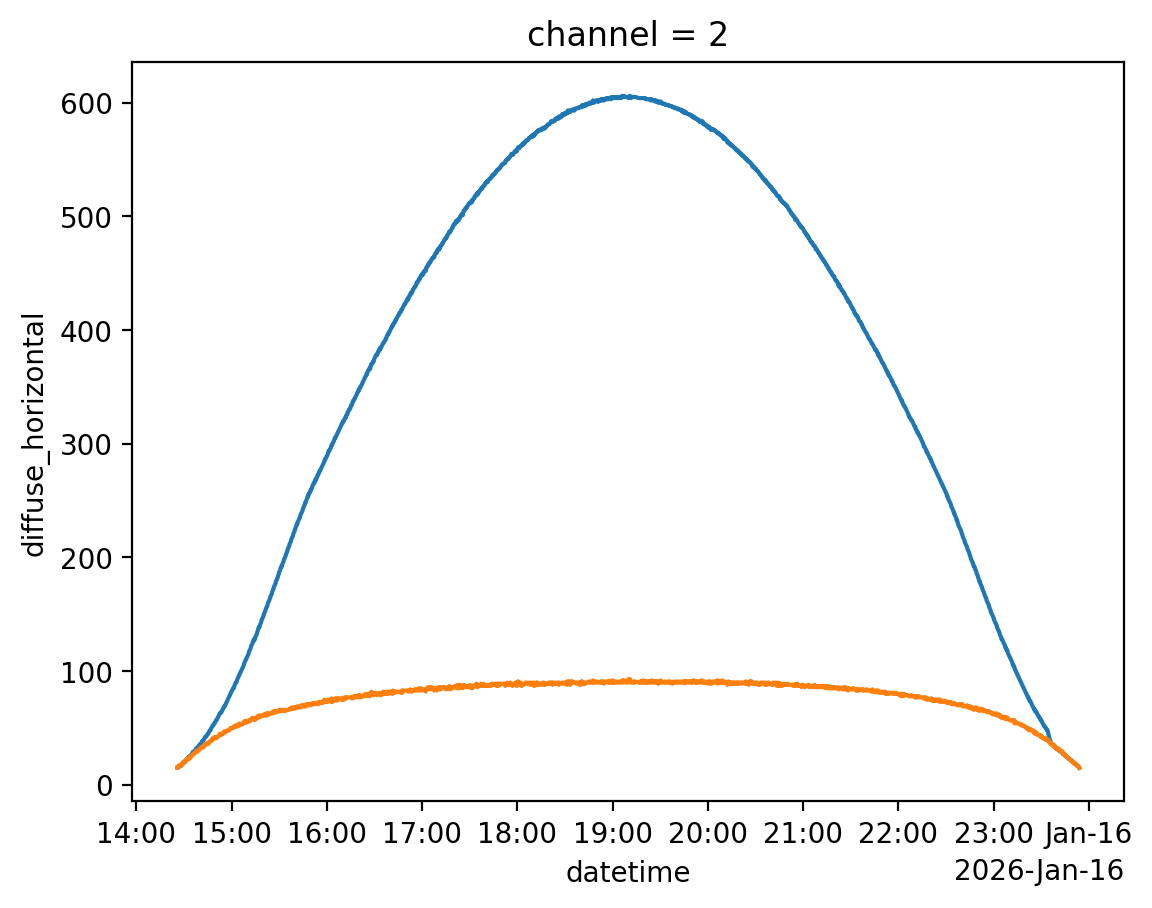

In [12]:
i = 14
# i += 1
print(i)
row = cal.workplan.iloc[i]
ds_raw = xr.open_dataset(row.p2f_in)
ds = ds_raw
ds.attrs['site_latitude'] = ds.attrs['latitude']
ds.attrs['site_longitude'] = ds.attrs['longitude']
ds.attrs['site_elevation'] = ds.attrs['elevation']


ch = 2
ds.global_horizontal.sel(channel = ch).plot()
ds.diffuse_horizontal.sel(channel = ch).plot()
print(row.p2f_in)

In [15]:
p2fcos

PosixPath('/Volumes/grad/Calibration_facilities/cucf/NOAA_GRAD_VisMFRSRs/V0660/Reported/V0660_20240208.cos')

In [16]:
reload(atmspc)
reload(atmspc.atmsol)

<module 'atmPy.radiation.solar' from '/Users/htelg/prog/atm-py/atmPy/radiation/solar.py'>

In [18]:
import atmPy.data_archives.NOAA_ESRL_GMD_GRAD.cal_facility.lab as atmcal

In [73]:
p2fcos = pl.Path('/Volumes/grad/Calibration_facilities/cucf/NOAA_GRAD_VisMFRSRs/V0660/Reported/V0660_20221109.cos')
p2fcos = pl.Path('/Volumes/grad/Calibration_facilities/cucf/NOAA_GRAD_VisMFRSRs/V0660/Reported/V0660_20240208.cos')

print(p2fcos)
ds_cosine = atmcal.read_mfrsr_cal_cos(p2fcos, reversed_EW=False, reversed_NS=False)

/Volumes/grad/Calibration_facilities/cucf/NOAA_GRAD_VisMFRSRs/V0660/Reported/V0660_20240208.cos


In [74]:
reload(atmcal)
reload(atmspc)

<module 'atmPy.radiation.instrumentation.spectral' from '/Users/htelg/prog/atm-py/atmPy/radiation/instrumentation/spectral.py'>

In [75]:
instument = atmspc.Mfrsr(
                        spectral_calibration = p2fspr,
                        logger_calibration = None, # note needed, we are not doing absolute calibration
                        head_calibration = None , # note needed, we are not doing absolute calibration
                        cosine_responds = ds_cosine
                        )

In [104]:
dscc = instument.raw2calibrated(ds_raw)

In [105]:
dscc

In [106]:
ds_raw

<xarray.Dataset> Size: 2MB
Dimensions:              (datetime: 4293, channel: 7)
Coordinates:
  * datetime             (datetime) datetime64[ns] 34kB 2026-01-15 ... 2026-0...
  * channel              (channel) int64 56B 0 1 2 3 4 5 6
Data variables: (12/14)
    alltime              (datetime, channel) float64 240kB ...
    global_horizontal    (datetime, channel) float64 240kB ...
    diffuse_horizontal   (datetime, channel) float64 240kB ...
    direct_horizontal    (datetime, channel) float64 240kB ...
    zenith               (datetime) float64 34kB 1.589 1.59 ... 1.575 1.576
    zenith_geometric     (datetime) float64 34kB 1.589 1.59 ... 1.583 1.584
    ...                   ...
    azimuth              (datetime) float64 34kB 4.238 4.238 ... 4.237 4.238
    equation_of_time     (datetime) float64 34kB -9.213 -9.213 ... -9.564 -9.564
    airmass              (datetime) float64 34kB nan nan nan nan ... nan nan nan
    airmass_absolute     (datetime) float64 34kB nan nan nan nan ... nan nan nan
    sun_earth_distance   (datetime) float64 34kB 0.9837 0.9837 ... 0.9837 0.9837
    direct_normal        (datetime, channel) float64 240kB nan nan ... nan nan
Attributes: (12/26)
    instrument:         mfrsr
    start_time:         2026-01-14 19:26:00
    avg_period:         20
    sample_rate:        20
    logger_id:          $D824
    head_id:            $3126
    ...                 ...
    sn_mfrsr:           660
    parent_files:       /Volumes/grad/Inst/MFR/SURFRAD/tbl/mfrsr/raw/2026/tbl...
    day_complete:       True
    site_latitude:      40.12498
    site_longitude:     -105.2368
    site_elevation:     1689

In [77]:
import scipy.integrate as spi

In [78]:
# add -90 and 90 if not present
# This is only so the integration goes all the way to pi/2 which impoves the normailiztion. The exact values at those angles should be irrelevant as cosine goes to zero, just infinit could be problementatic
ds = instument.cosine_responds.copy()

if -90 not in ds.Angle:
    dsother = ds.sel(Angle = -89)
    dsother.Angle.data = -90
    ds = xr.concat([dsother,ds], 'Angle')
if 90 not in ds.Angle:
    dsother = ds.sel(Angle = 89)
    dsother.Angle.data = 90
    ds = xr.concat([ds, dsother], 'Angle')

# do the integration
ang = np.deg2rad(ds.Angle).data
norm = spi.simpson(np.cos(ang), ang)
toll = 1e-8
test = abs(norm - 2)
assert(test < toll), f'Integral over the cos(angle) is expected to be close to 2. It is {norm}, which is larger than the tolerance of {toll}. Check for problems in the cosine responds data or increase tollerance (if you are really sure)'

# da = ds.spectral_NS
resNS = spi.simpson(ds.spectral_NS * np.cos(ang), ang)/norm
resEW = spi.simpson(ds.spectral_EW * np.cos(ang), ang)/norm
res = (resNS + resEW)/2

ds['spectral_diffuse'] = ('channel', res)

resNS = spi.simpson(ds.broadband_NS * np.cos(ang), ang)/norm
resEW = spi.simpson(ds.broadband_EW * np.cos(ang), ang)/norm

res = (resNS + resEW)/2

ds['broadband_diffuse'] = res

# cosine correction comparison

## what cosine correction was applied?

In [79]:
import atmPy.data_archives.NOAA_ESRL_GMD_GRAD.surfrad.surfrad as atmsrf

In [80]:
instument.cosine_calibration_diffuse

<xarray.DataArray 'spectral_diffuse' (channel: 6)> Size: 48B
array([1.02041126, 1.02060388, 1.01104469, 1.01881371, 1.01550616,
       1.01551129])
Coordinates:
  * channel  (channel) int64 48B 415 500 1625 670 870 940

In [81]:
1/ds.spectral_diffuse

<xarray.DataArray 'spectral_diffuse' (channel: 6)> Size: 48B
array([1.02041126, 1.02060388, 1.01104469, 1.01881371, 1.01550616,
       1.01551129])
Coordinates:
  * channel  (channel) int64 48B 415 500 1625 670 870 940

In [82]:
# si_tu = atmsrf.read_ccc(pl.Path('/Volumes/grad/Inst/MFR/SURFRAD/tbl/mfrsr/tu/2026/tbl_mfrsr_20260106_D824_3126_660.tu'), raisefilterfunctionerror=False)
si_tu = atmsrf.read_ccc(pl.Path('/Volumes/grad/Inst/MFR/SURFRAD/tbl/mfrsr/tu/2026/tbl_mfrsr_20260115_D824_3126_660.tu'), raisefilterfunctionerror=False)

si_tu.dataset = si_tu.dataset.reindex(datetime = ds_raw.datetime, method='bfill')
si_tu.dataset = si_tu.dataset.rename({'direct_normal_irradiation': 'direct_normal', 'diffuse_horizontal_irradiation': 'diffuse_horizontal', 'global_horizontal_irradiation': 'global_horizontal'})

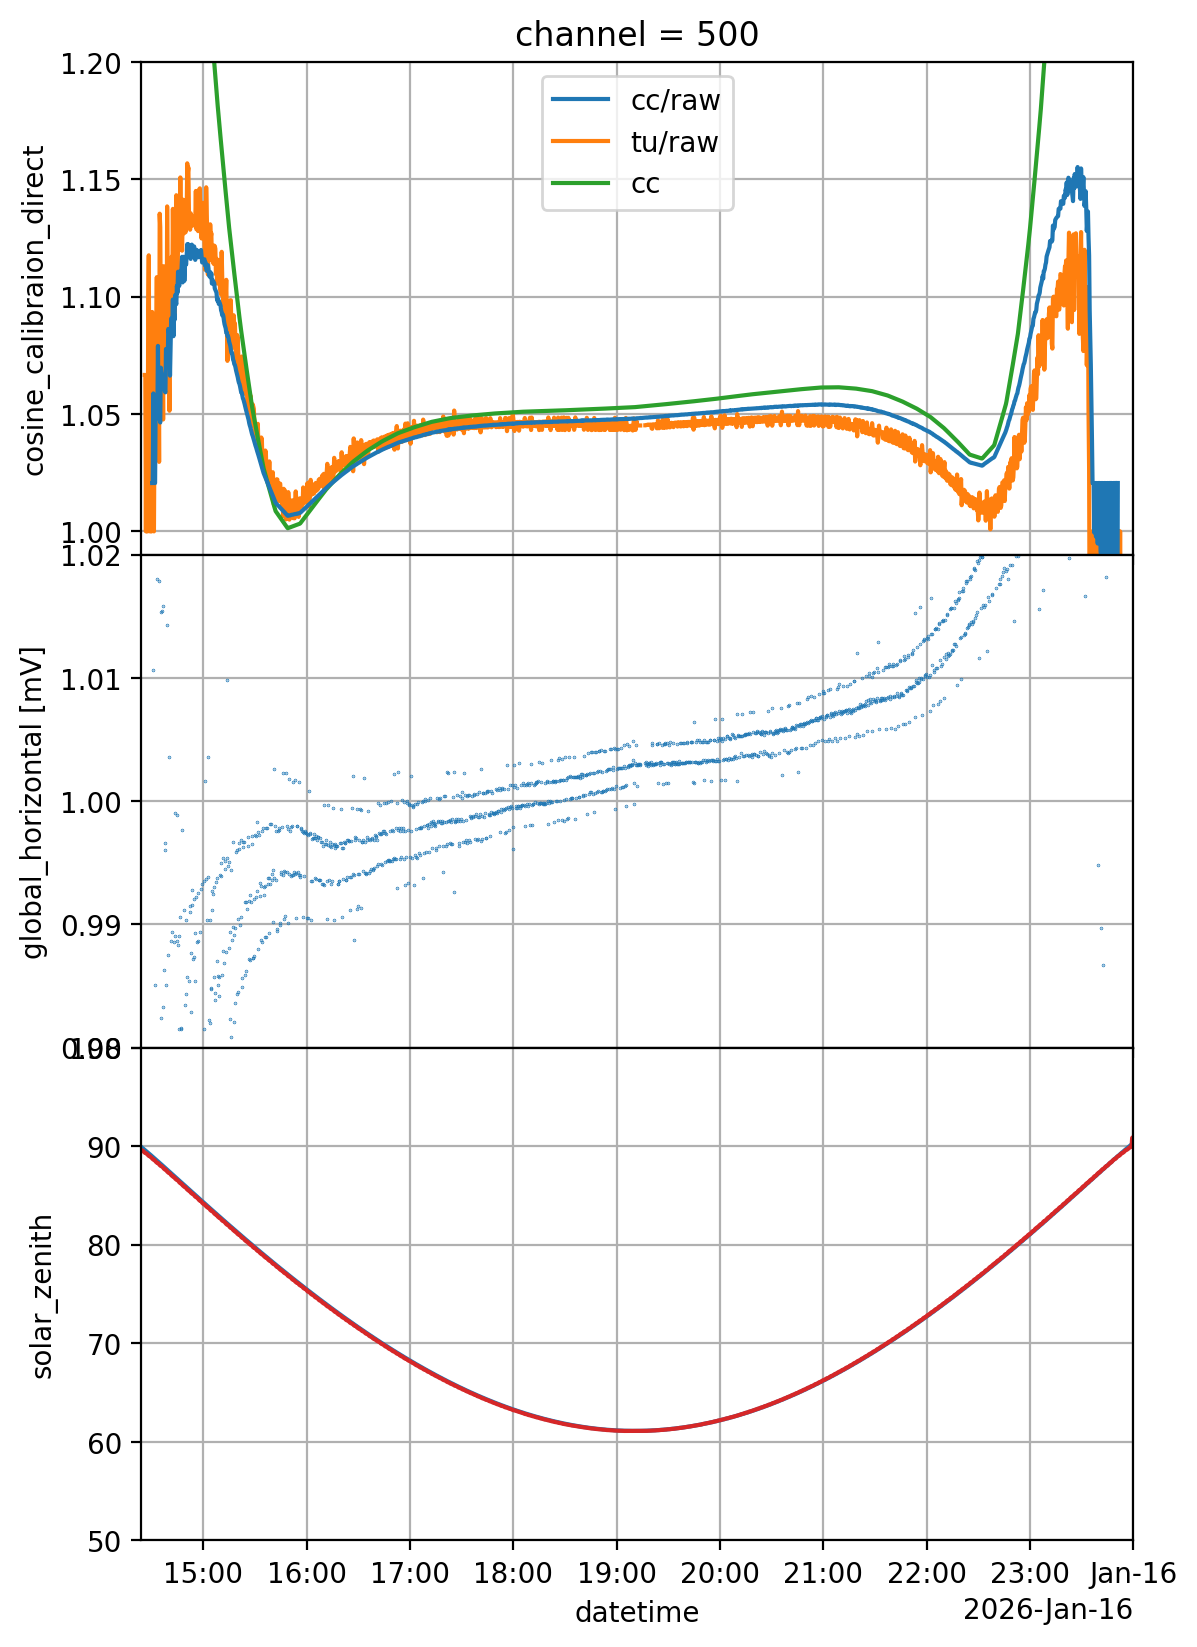

In [83]:
ch = 2
wl = 500
f,aa = plt.subplots(3, sharex = True, gridspec_kw={'hspace':0})
f.set_figheight(f.get_figheight() * 2)
what = 'global_horizontal'
# what = 'direct_normal'
# what = 'diffuse_horizontal'
a = aa[0]

dscc.dataset[what]
# ds_raw[what]
(dscc.dataset[what].sel(channel = wl) / si_raw.direct_normal_irradiation.dataset[what].sel(channel = ch)).plot(ax = a, label = 'cc/raw', zorder = 10)
(si_tu.dataset[what].sel(channel = wl) / ds_raw[what].sel(channel = ch)).plot(ax = a, label = 'tu/raw')
# (1/out.sel(channel = wl)).plot(ax = a)
dscc.dataset.cosine_calibraion_direct.sel(channel = wl).plot(ax = a, label = 'cc')

a.legend()
a.set_ylim(0.99, 1.2)

a = aa[2]
np.rad2deg(dscc.sun_position.zenith).plot(ax = a, label = 'zenith')
np.rad2deg(dscc.sun_position.azimuth).plot(ax = a, label = 'azimuth')

si_tu.dataset.solar_azimuth.plot()
si_tu.dataset.solar_zenith.plot()
a.set_ylim(50, 100)

a = aa[1]
((dscc.dataset[what].sel(channel = wl) / ds_raw[what].sel(channel = ch)) / (si_tu.dataset[what].sel(channel = wl) / ds_raw[what].sel(channel = ch))).plot(ax = a, label = 'tu/raw', ls = '', marker = '.', markersize = 0.5)
a.set_ylim(0.98, 1.02)
a.set_xlim(np.float64(20468.6), np.float64(20469.0))

for a in aa:
    a.grid(True)


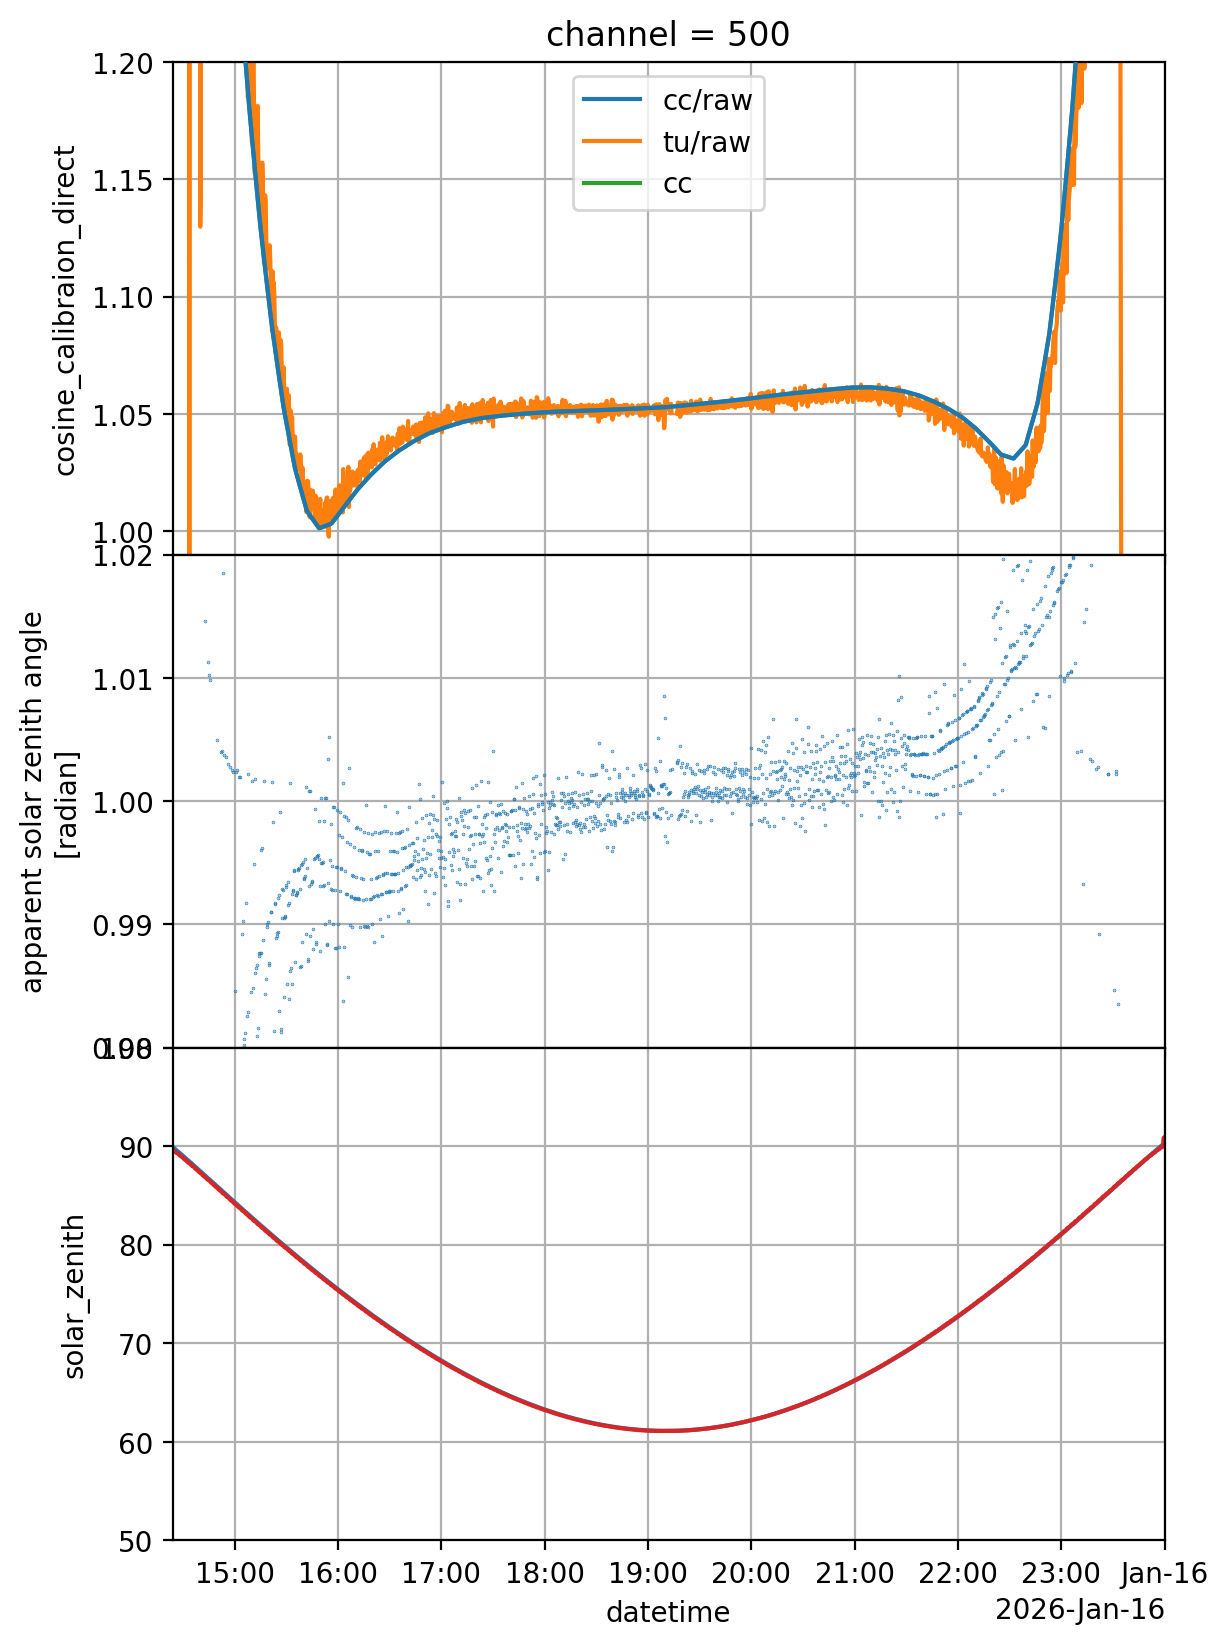

In [84]:
ch = 2
wl = 500
f,aa = plt.subplots(3, sharex = True, gridspec_kw={'hspace':0})
f.set_figheight(f.get_figheight() * 2)
what = 'global_horizontal'
what = 'direct_normal'
# what = 'diffuse_horizontal'
a = aa[0]

dscc.dataset[what]
# ds_raw[what]
(dscc.dataset[what].sel(channel = wl) / si_raw.direct_normal_irradiation.dataset[what].sel(channel = ch)).plot(ax = a, label = 'cc/raw', zorder = 10)
(si_tu.dataset[what].sel(channel = wl) / ds_raw[what].sel(channel = ch)).plot(ax = a, label = 'tu/raw')
# (1/out.sel(channel = wl)).plot(ax = a)
dscc.dataset.cosine_calibraion_direct.sel(channel = wl).plot(ax = a, label = 'cc')

a.legend()
a.set_ylim(0.99, 1.2)

a = aa[2]
np.rad2deg(dscc.sun_position.zenith).plot(ax = a, label = 'zenith')
np.rad2deg(dscc.sun_position.azimuth).plot(ax = a, label = 'azimuth')

si_tu.dataset.solar_azimuth.plot()
si_tu.dataset.solar_zenith.plot()
a.set_ylim(50, 100)

a = aa[1]
((dscc.dataset[what].sel(channel = wl) / ds_raw[what].sel(channel = ch)) / (si_tu.dataset[what].sel(channel = wl) / ds_raw[what].sel(channel = ch))).plot(ax = a, label = 'tu/raw', ls = '', marker = '.', markersize = 0.5)
a.set_ylim(0.98, 1.02)
a.set_xlim(np.float64(20468.6), np.float64(20469.0))

for a in aa:
    a.grid(True)


(np.float64(20468.5), np.float64(20469.049756944445))

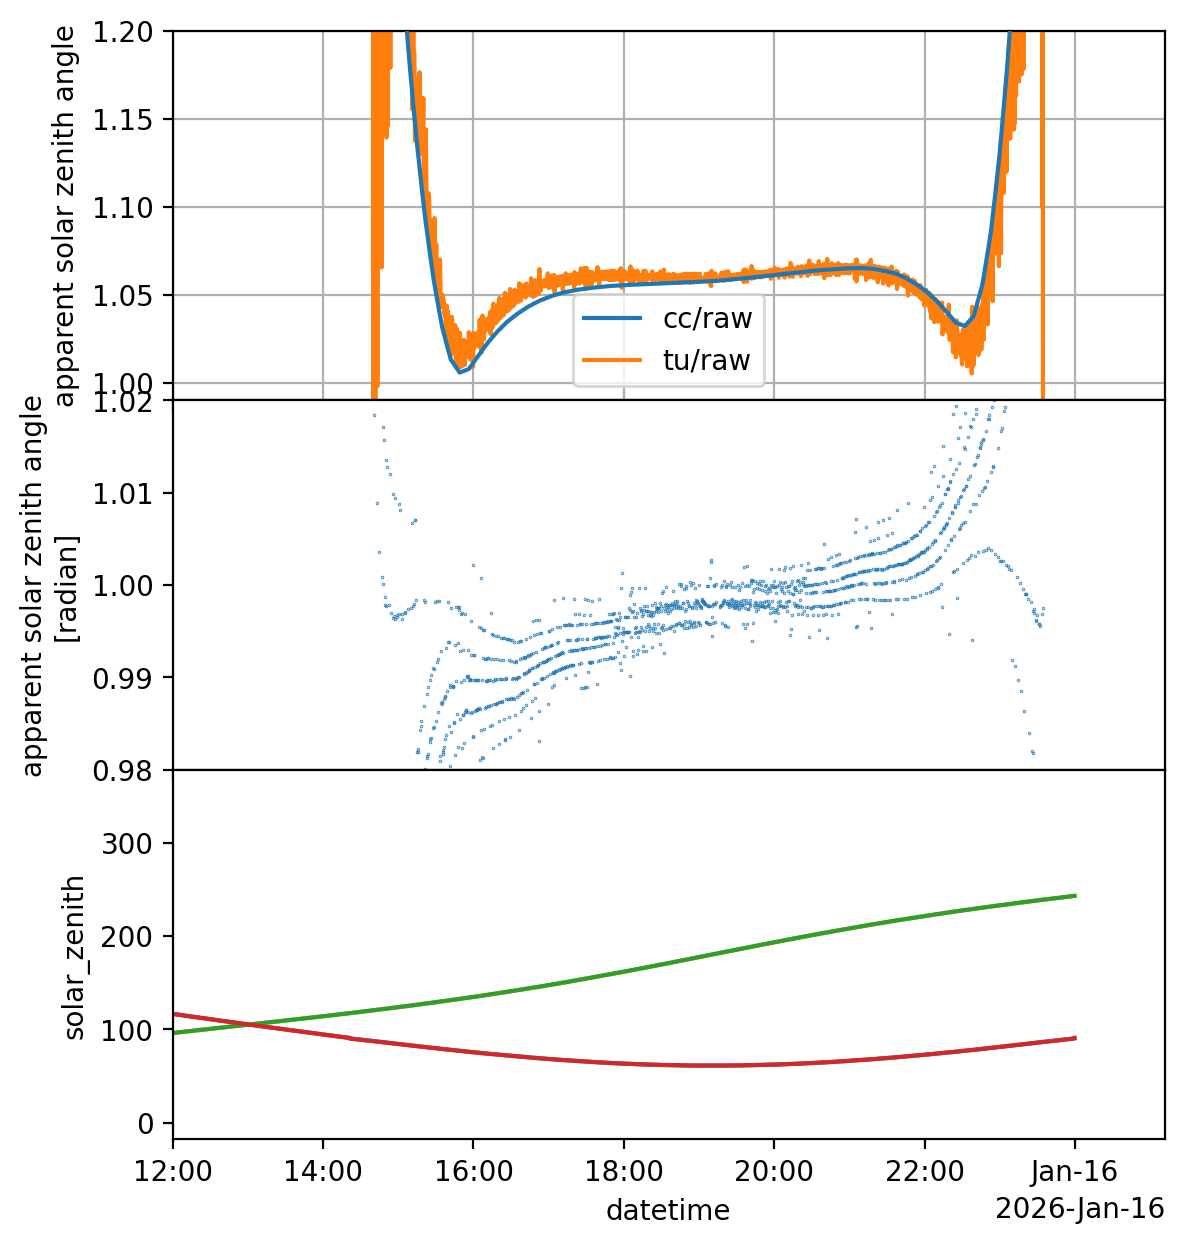

In [85]:
ch = 1
wl = 415
f,aa = plt.subplots(3, sharex = True, gridspec_kw={'hspace':0})
f.set_figheight(f.get_figheight() * 1.5)
what = 'global_horizontal'
what = 'direct_normal'
# what = 'diffuse_horizontal'
a = aa[0]
(dscc.dataset[what].sel(channel = wl) / ds_raw[what].sel(channel = ch)).plot(ax = a, label = 'cc/raw', zorder = 10)
(si_tu.dataset[what].sel(channel = wl) / ds_raw[what].sel(channel = ch)).plot(ax = a, label = 'tu/raw')
# (1/out.sel(channel = wl)).plot(ax = a)
# dscc.dataset.cosine_calibraion_direct.sel(channel = wl).plot(ax = a, label = 'cc')

a.legend()
a.set_ylim(0.99, 1.2)
a.grid(True)

a = aa[2]
np.rad2deg(dscc.sun_position.zenith).plot(ax = a, label = 'zenith')
np.rad2deg(dscc.sun_position.azimuth).plot(ax = a, label = 'azimuth')

si_tu.dataset.solar_azimuth.plot()
si_tu.dataset.solar_zenith.plot()

a = aa[1]
((dscc.dataset[what].sel(channel = wl) / ds_raw[what].sel(channel = ch)) / (si_tu.dataset[what].sel(channel = wl) / ds_raw[what].sel(channel = ch))).plot(ax = a, label = 'tu/raw', ls = '', marker = '.', markersize = 0.5)
a.set_ylim(0.98, 1.02)

a.set_xlim(np.float64(20468.5), np.float64(20469.049756944445))


(np.float64(20468.5), np.float64(20469.049756944445))

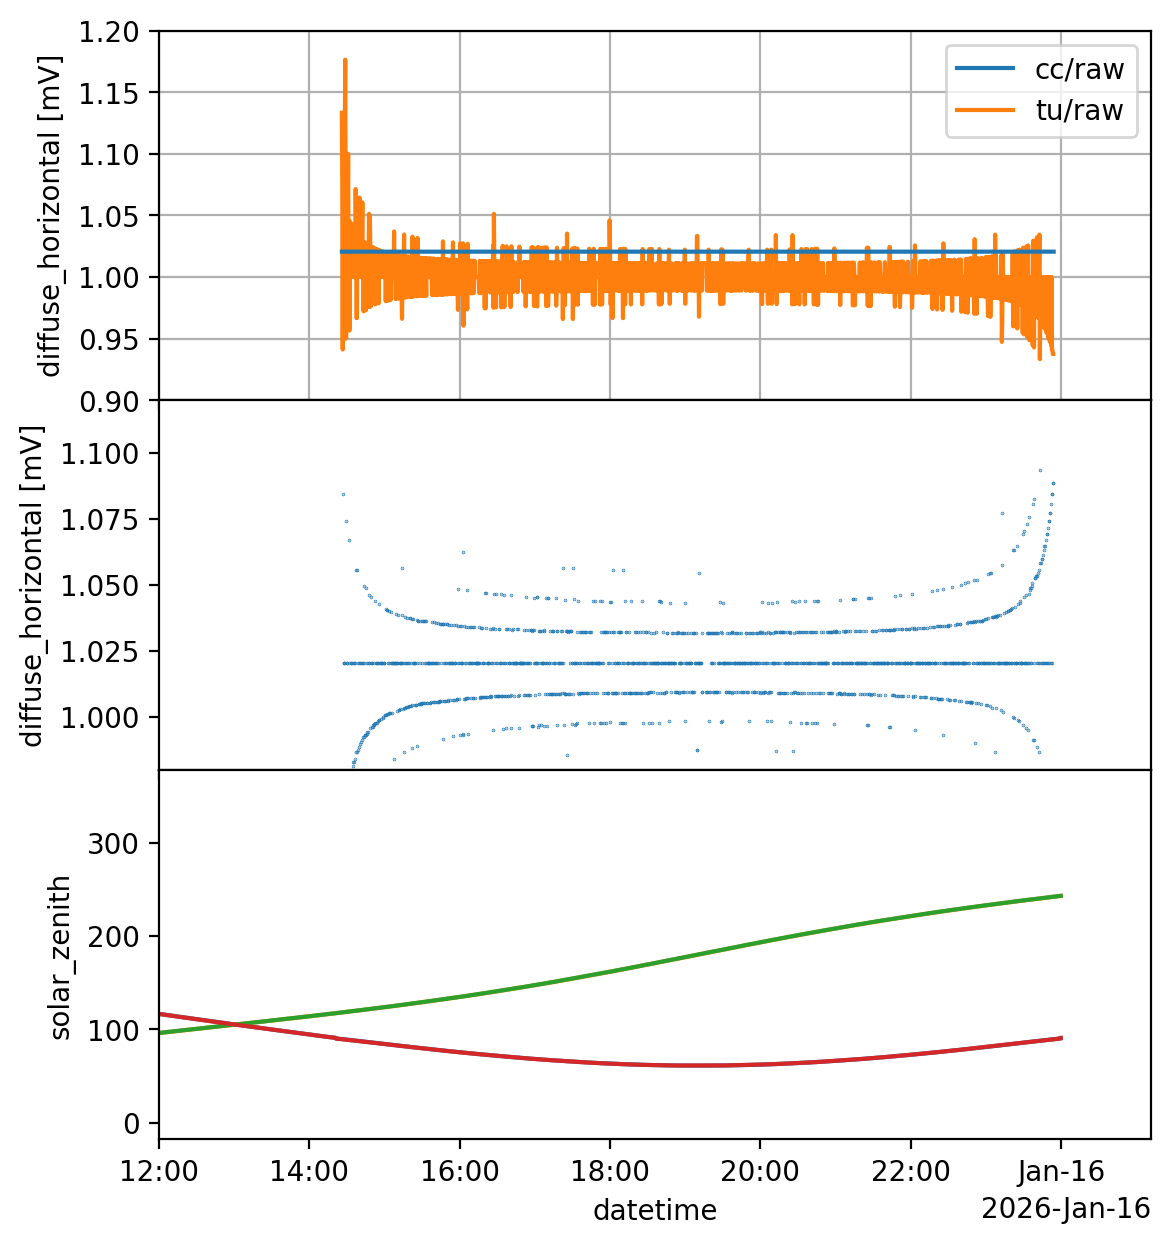

In [86]:
ch = 2
wl = 500
f,aa = plt.subplots(3, sharex = True, gridspec_kw={'hspace':0})
f.set_figheight(f.get_figheight() * 1.5)
what = 'global_horizontal'
what = 'direct_normal'
what = 'diffuse_horizontal'
a = aa[0]
(dscc.dataset[what].sel(channel = wl) / ds_raw[what].sel(channel = ch)).plot(ax = a, label = 'cc/raw', zorder = 10)
(si_tu.dataset[what].sel(channel = wl) / ds_raw[what].sel(channel = ch)).plot(ax = a, label = 'tu/raw')
# (1/out.sel(channel = wl)).plot(ax = a)
# dscc.dataset.cosine_calibraion_direct.sel(channel = wl).plot(ax = a, label = 'cc')

a.legend()
a.set_ylim(0.9, 1.2)
a.grid(True)

a = aa[2]
np.rad2deg(dscc.sun_position.zenith).plot(ax = a, label = 'zenith')
np.rad2deg(dscc.sun_position.azimuth).plot(ax = a, label = 'azimuth')

si_tu.dataset.solar_azimuth.plot()
si_tu.dataset.solar_zenith.plot()

a = aa[1]
((dscc.dataset[what].sel(channel = wl) / ds_raw[what].sel(channel = ch)) / (si_tu.dataset[what].sel(channel = wl) / ds_raw[what].sel(channel = ch))).plot(ax = a, label = 'tu/raw', ls = '', marker = '.', markersize = 0.5)
a.set_ylim(0.98, 1.12)

a.set_xlim(np.float64(20468.5), np.float64(20469.049756944445))


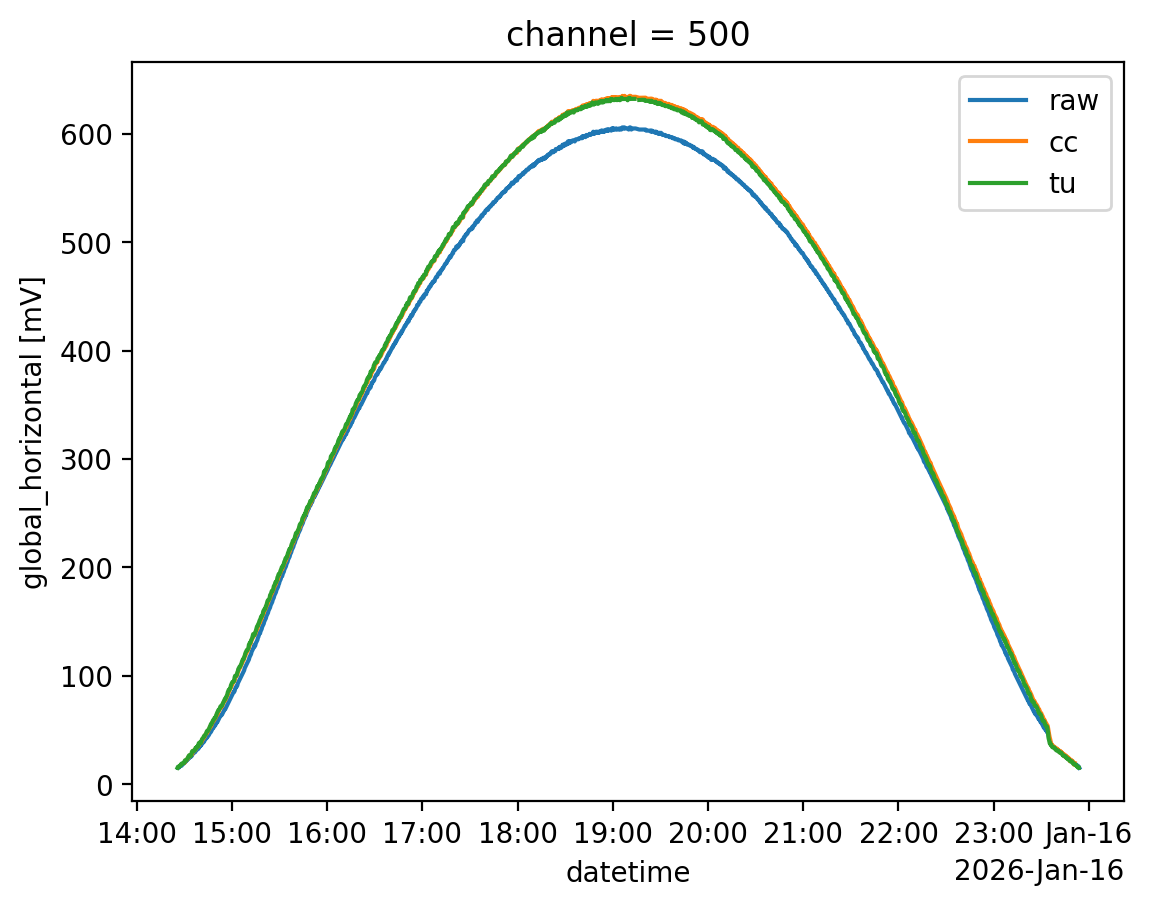

In [87]:
ch = 2
wl = 500
f,a = plt.subplots()
ds_raw.global_horizontal.sel(channel = ch).plot(ax = a, label = 'raw')
dscc.dataset.global_horizontal.sel(channel = wl).plot(ax = a, label = 'cc')
si_tu.dataset.global_horizontal.sel(channel = wl).plot(ax = a, label = 'tu')


a.legend()

In [88]:
amr = [2.2,4]

In [89]:
si_raw.direct_normal_irradiation._am = None
si_raw.direct_normal_irradiation._pm = None
si_raw.direct_normal_irradiation.settings_langley_airmass_limits = amr

In [90]:
dscc.direct_normal_irradiation._am = None
dscc.direct_normal_irradiation._pm = None
dscc.direct_normal_irradiation.settings_langley_airmass_limits = amr

In [91]:
si_tu.direct_normal_irradiation._am = None
si_tu.direct_normal_irradiation._pm = None
si_tu.direct_normal_irradiation.settings_langley_airmass_limits = amr

## am

/Users/htelg/miniconda3/envs/py13/lib/python3.13/site-packages/xarray/computation/apply_ufunc.py:820: RuntimeWarning: divide by zero encountered in log
  result_data = func(*input_data)


(<Figure size 1280x960 with 1 Axes>, <Axes: xlabel='airmass'>)

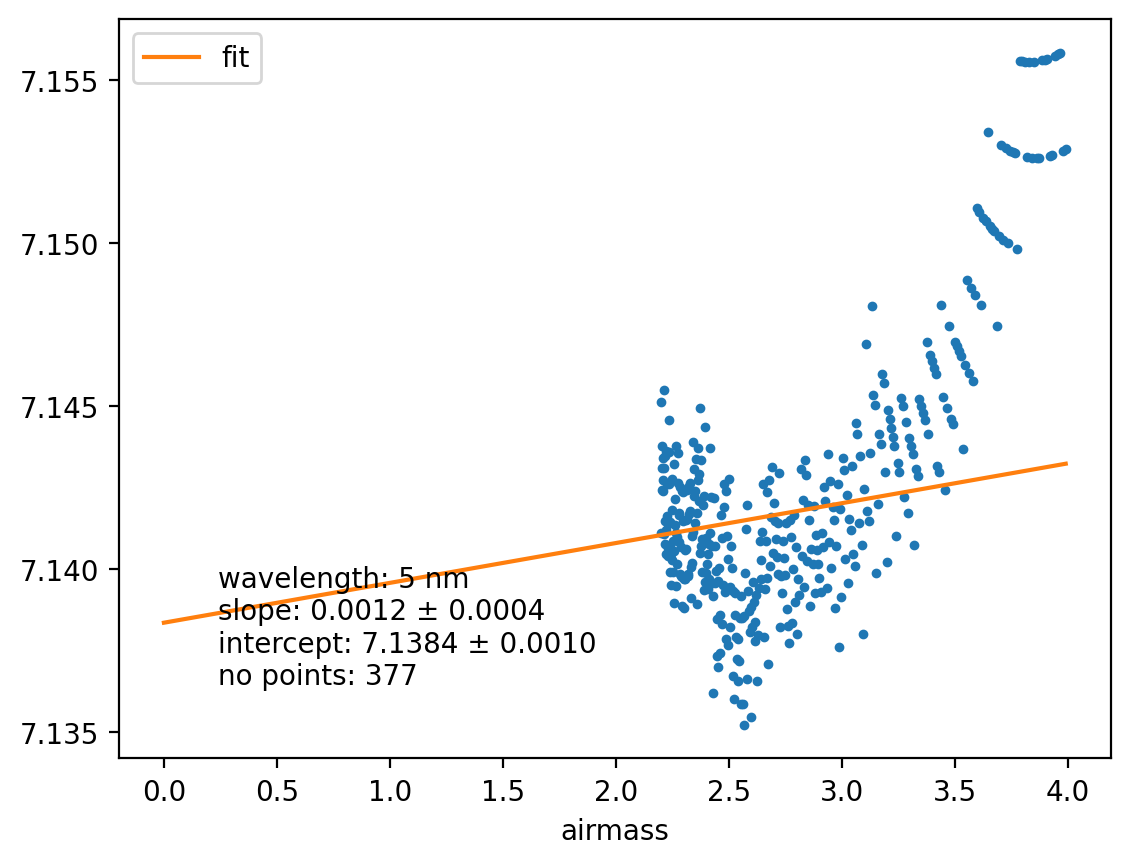

In [92]:

si_raw.direct_normal_irradiation.langley_am.plot(wavelength=5, show_pre_clean=False)

/Users/htelg/miniconda3/envs/py13/lib/python3.13/site-packages/xarray/computation/apply_ufunc.py:820: RuntimeWarning: divide by zero encountered in log
  result_data = func(*input_data)
/Users/htelg/miniconda3/envs/py13/lib/python3.13/site-packages/xarray/computation/apply_ufunc.py:820: RuntimeWarning: invalid value encountered in log
  result_data = func(*input_data)


(<Figure size 1280x960 with 1 Axes>, <Axes: xlabel='airmass'>)

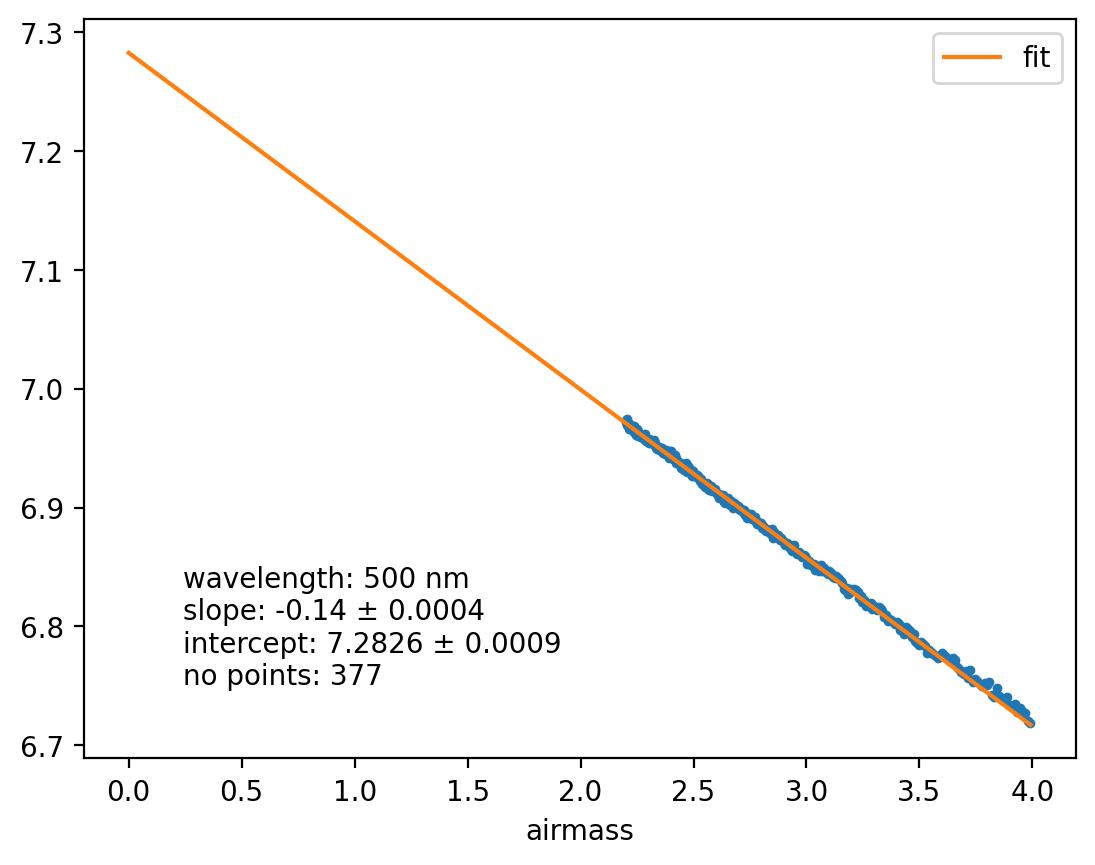

In [93]:
dscc.direct_normal_irradiation.langley_am.plot(wavelength=500, show_pre_clean=False)

(<Figure size 1280x960 with 1 Axes>, <Axes: xlabel='airmass'>)

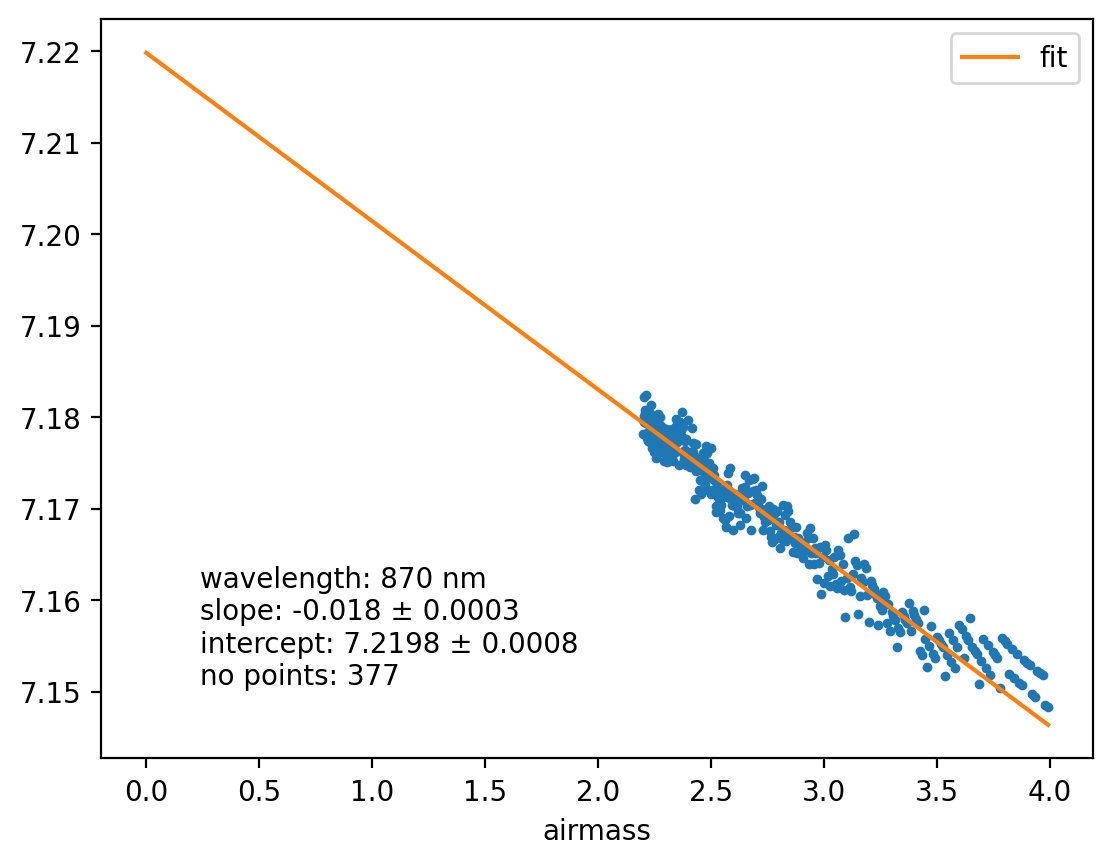

In [94]:
dscc.direct_normal_irradiation.langley_am.plot(wavelength=870, show_pre_clean=False)

original columns: ['apparent_zenith', 'zenith', 'apparent_elevation', 'elevation', 'azimuth', 'equation_of_time']


/Users/htelg/miniconda3/envs/py13/lib/python3.13/site-packages/xarray/computation/apply_ufunc.py:820: RuntimeWarning: divide by zero encountered in log
  result_data = func(*input_data)


(<Figure size 1280x960 with 1 Axes>, <Axes: xlabel='airmass'>)

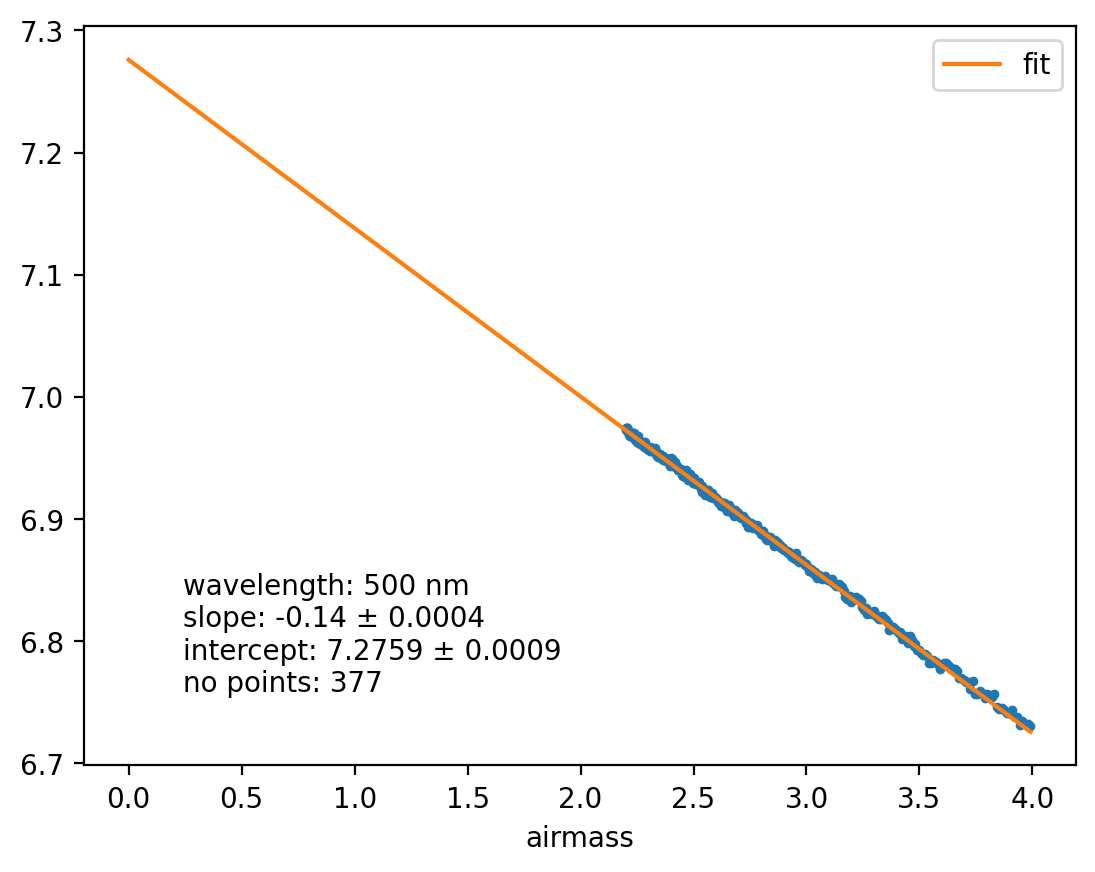

In [95]:
si_tu.direct_normal_irradiation.langley_am.plot(wavelength=500, show_pre_clean=False)

(<Figure size 1280x960 with 1 Axes>, <Axes: xlabel='airmass'>)

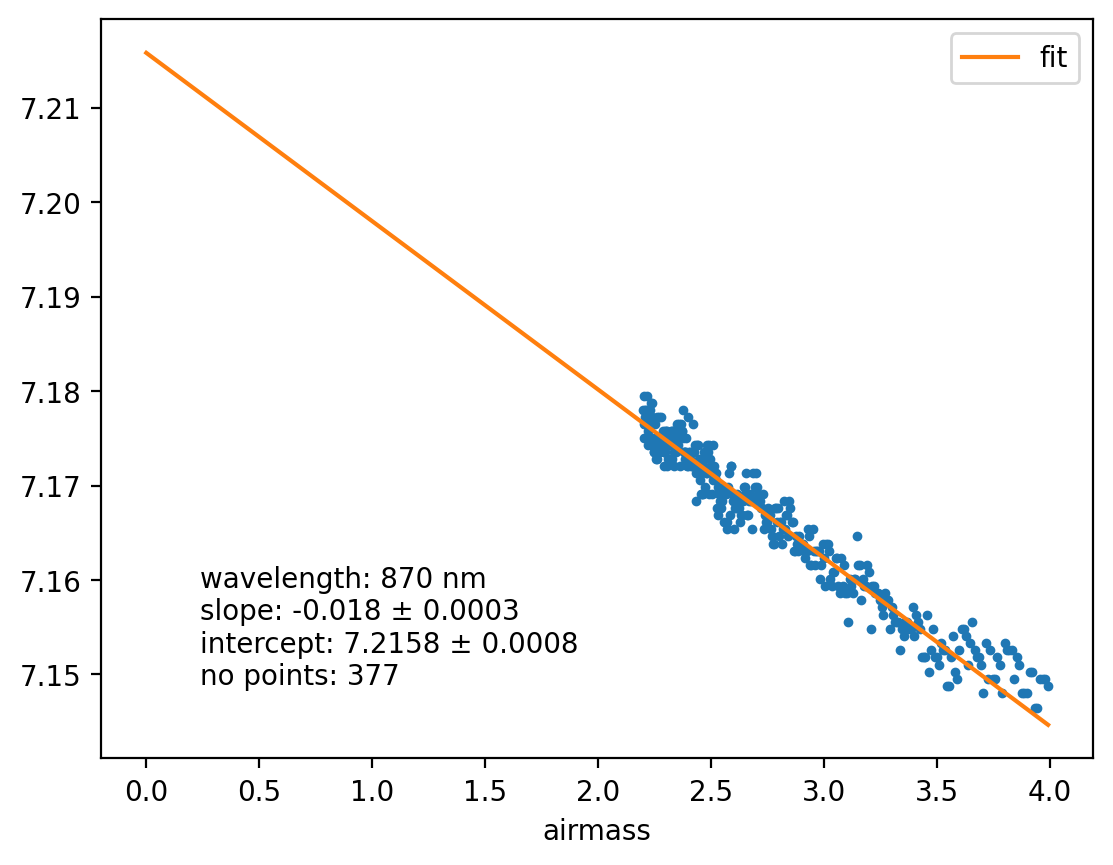

In [96]:
si_tu.direct_normal_irradiation.langley_am.plot(wavelength=870, show_pre_clean=False)

## pm

(<Figure size 1280x960 with 1 Axes>, <Axes: xlabel='airmass'>)

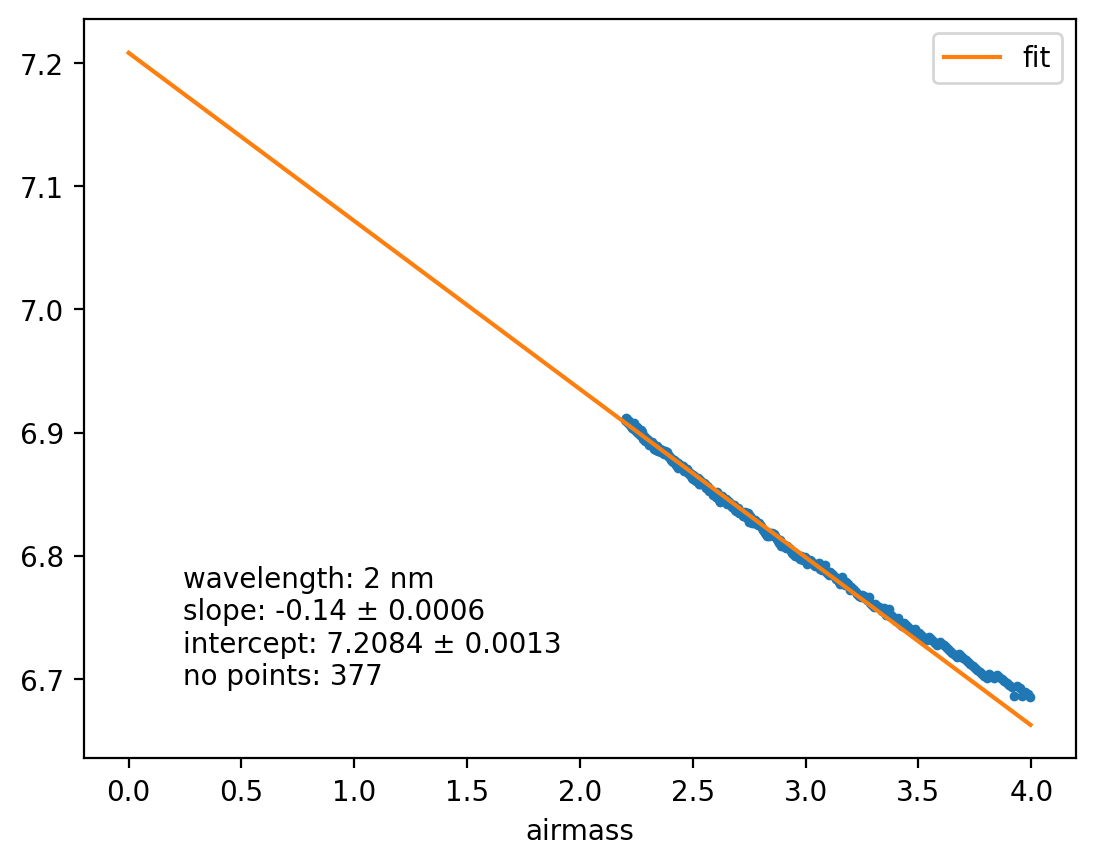

In [97]:
si_raw.direct_normal_irradiation.langley_pm.plot(wavelength=2, show_pre_clean=False)

(<Figure size 1280x960 with 1 Axes>, <Axes: xlabel='airmass'>)

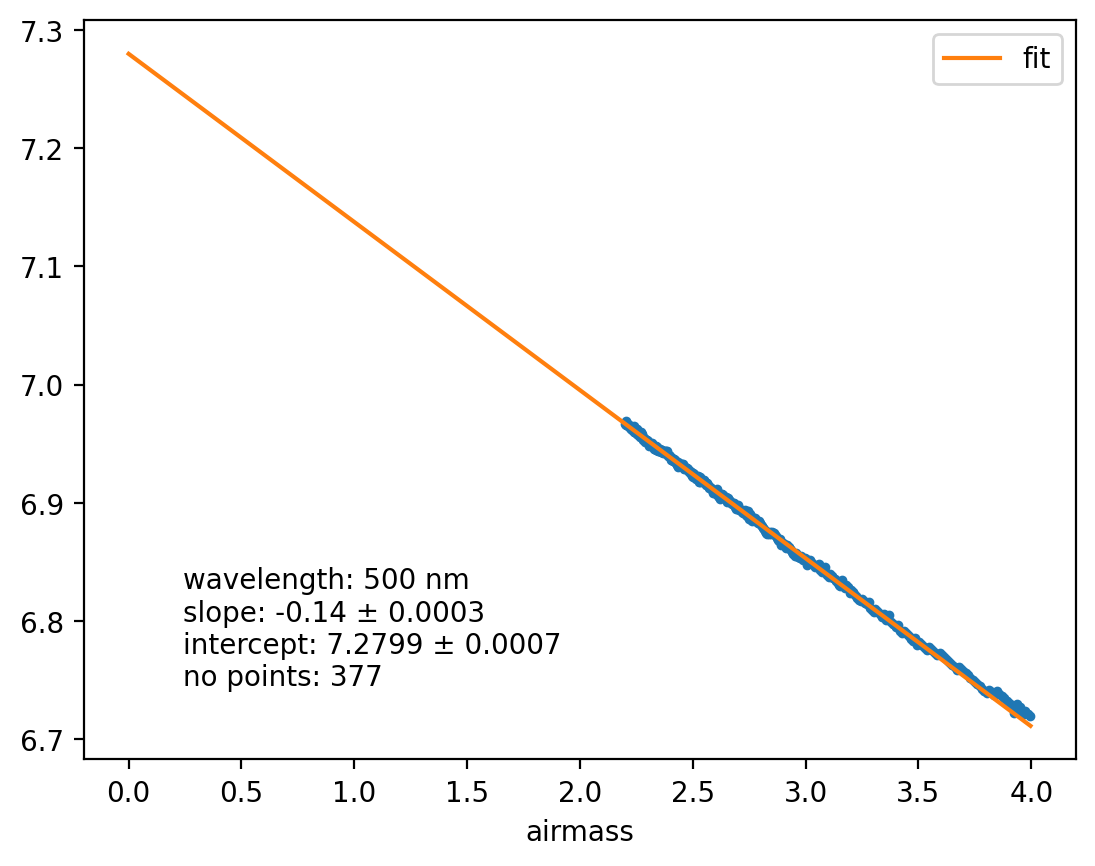

In [98]:
dscc.direct_normal_irradiation.langley_pm.plot(wavelength=500, show_pre_clean=False)

(<Figure size 1280x960 with 1 Axes>, <Axes: xlabel='airmass'>)

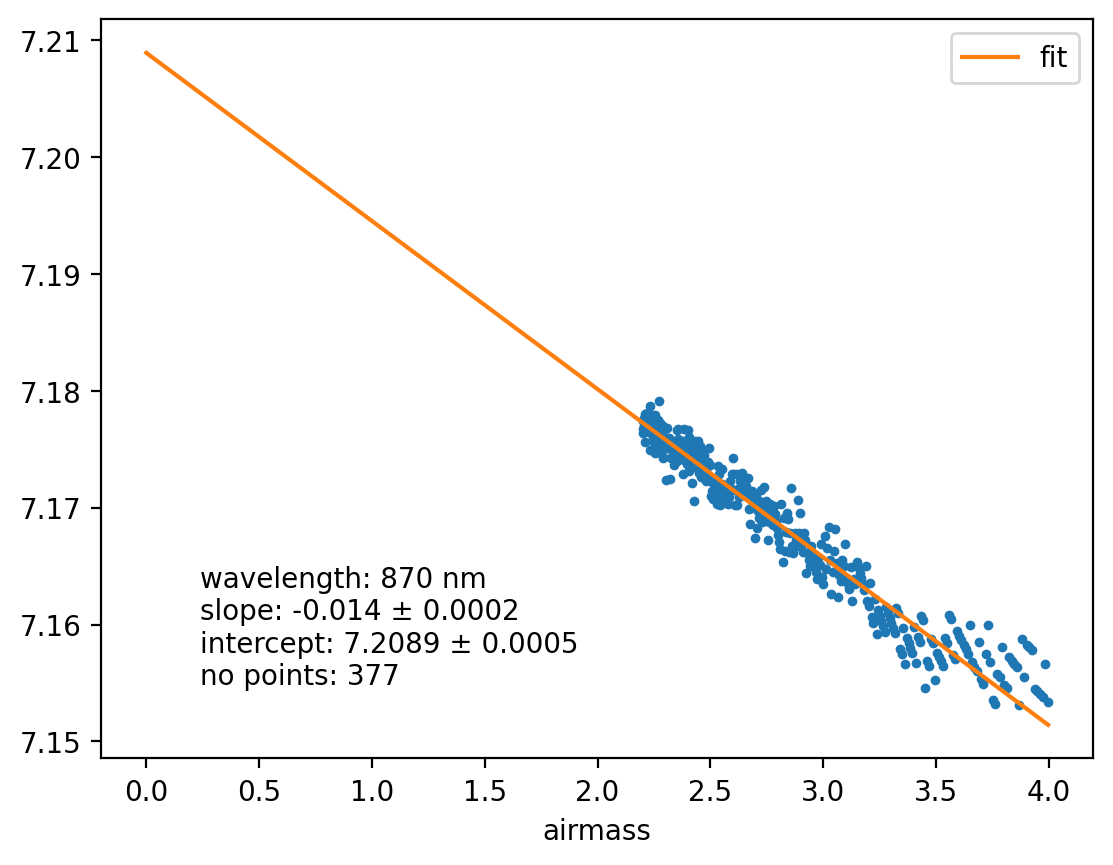

In [99]:
dscc.direct_normal_irradiation.langley_pm.plot(wavelength=870, show_pre_clean=False)

(<Figure size 1280x960 with 1 Axes>, <Axes: xlabel='airmass'>)

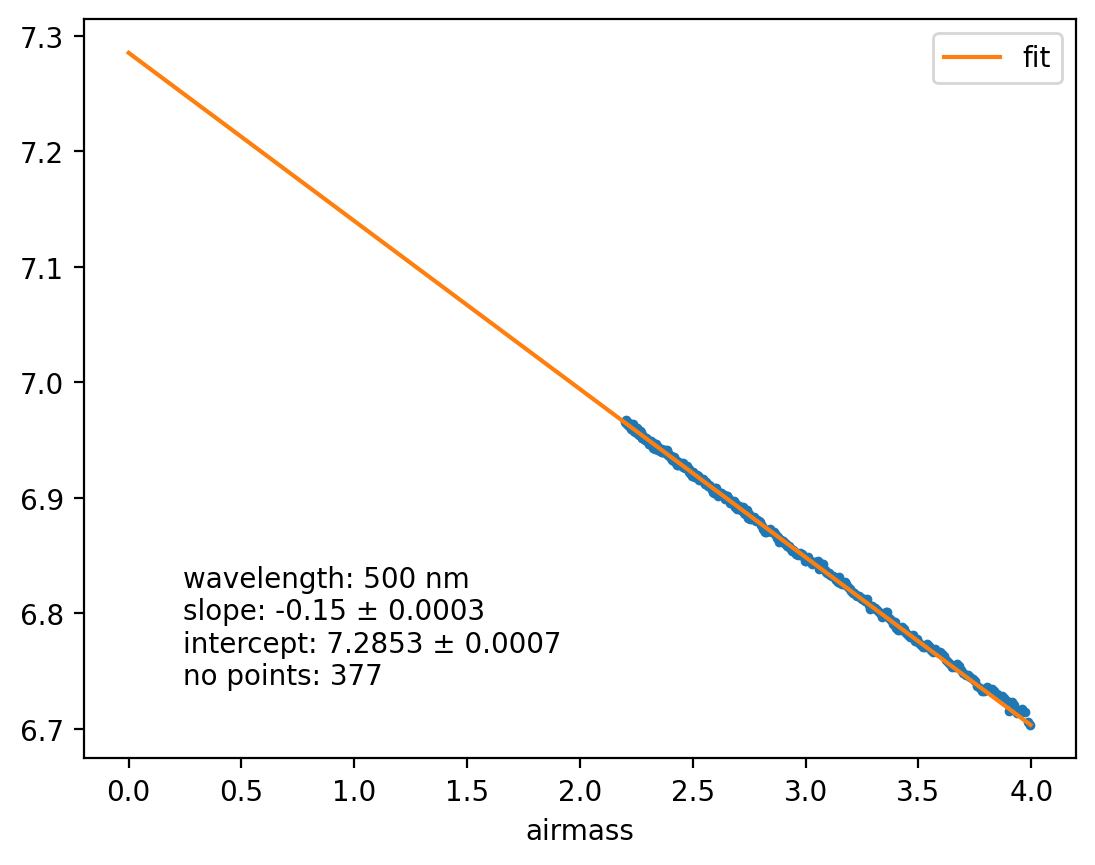

In [100]:
si_tu.direct_normal_irradiation.langley_pm.plot(wavelength=500, show_pre_clean=False)

(<Figure size 1280x960 with 1 Axes>, <Axes: xlabel='airmass'>)

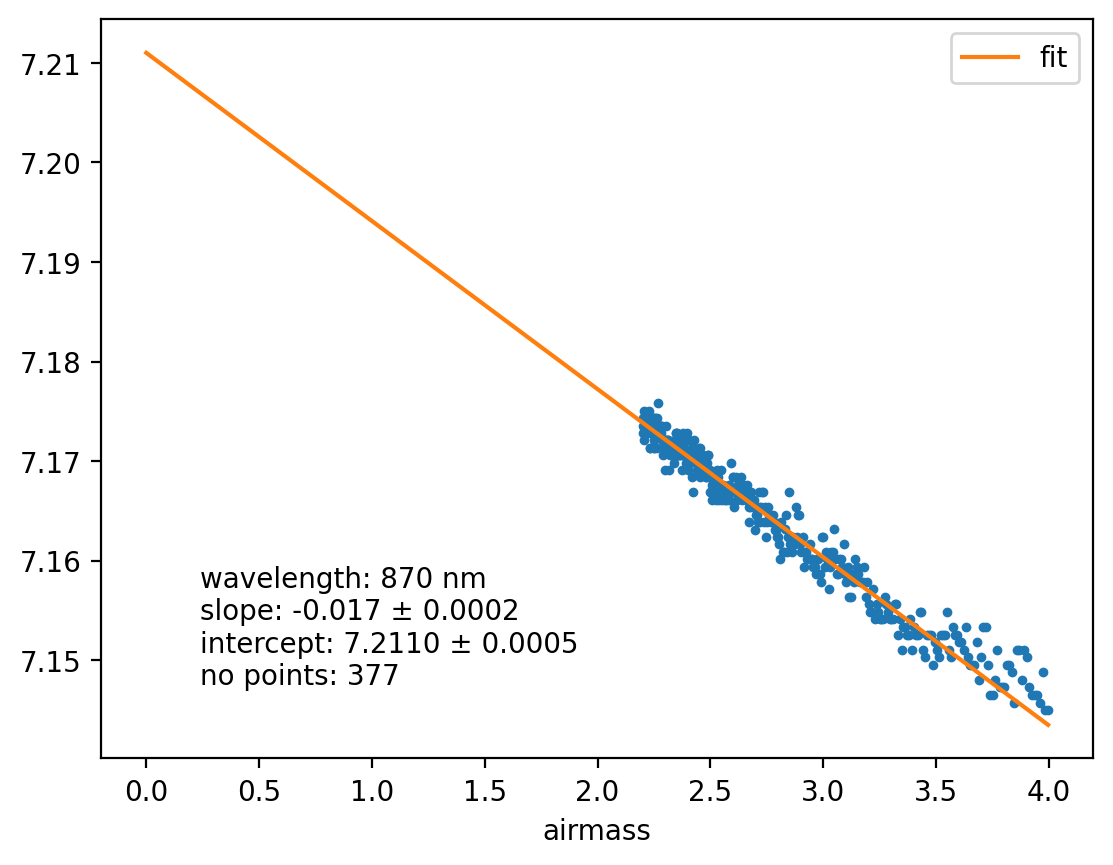

In [101]:
si_tu.direct_normal_irradiation.langley_pm.plot(wavelength=870, show_pre_clean=False)

In [102]:
df = pd.DataFrame()
df['dscc_am'] = dscc.direct_normal_irradiation.langley_am.langley_fitres.intercept
df['tu_am'] = si_tu.direct_normal_irradiation.langley_am.langley_fitres.intercept
df['dscc_pm'] = dscc.direct_normal_irradiation.langley_pm.langley_fitres.intercept
df['tu_pm'] = si_tu.direct_normal_irradiation.langley_pm.langley_fitres.intercept

# df['tu_ratio'] = df.tu_am/df.tu_pm
# df['tu_dif'] = df.tu_am - df.tu_pm
# df['dscc_dif'] = df.dscc_am - df.dscc_pm

df['tu_dif'] = np.exp(df.tu_am) - np.exp(df.tu_pm)
df['dscc_dif'] = np.exp(df.dscc_am) - np.exp(df.dscc_pm)

df['tu_uc'] = df.tu_dif / np.exp(df.tu_am)
df['dscc_uc'] = df.dscc_dif / np.exp(df.dscc_am)


df

,dscc_am,tu_am,dscc_pm,tu_pm,tu_dif,dscc_dif,tu_uc,dscc_uc
wavelength,,,,,,,,
415,7.454939,7.448135,7.449462,7.461111,-22.420328,9.440761,-0.013060,0.005462
500,7.282632,7.275883,7.279888,7.285342,-13.734622,3.986079,-0.009505,0.002740
670,6.968979,6.964041,6.964744,6.967620,-3.792674,4.493760,-0.003585,0.004227
870,7.219812,7.215801,7.208926,7.211007,6.507991,14.791769,0.004783,0.010827
940,7.432150,7.429051,7.141547,7.138071,425.211942,426.055187,0.252470,0.252188
1625,6.262620,6.254115,6.252898,6.247222,3.572971,5.075673,0.006869,0.009675


In [67]:
df = pd.DataFrame()
df['dscc_am'] = dscc.direct_normal_irradiation.langley_am.langley_fitres.intercept
df['tu_am'] = si_tu.direct_normal_irradiation.langley_am.langley_fitres.intercept
df['dscc_pm'] = dscc.direct_normal_irradiation.langley_pm.langley_fitres.intercept
df['tu_pm'] = si_tu.direct_normal_irradiation.langley_pm.langley_fitres.intercept

# df['tu_ratio'] = df.tu_am/df.tu_pm
# df['tu_dif'] = df.tu_am - df.tu_pm
# df['dscc_dif'] = df.dscc_am - df.dscc_pm

df['tu_dif'] = np.exp(df.tu_am) - np.exp(df.tu_pm)
df['dscc_dif'] = np.exp(df.dscc_am) - np.exp(df.dscc_pm)

df['tu_uc'] = df.tu_dif / np.exp(df.tu_am)
df['dscc_uc'] = df.dscc_dif / np.exp(df.dscc_am)


df

In [68]:
np.exp(df.tu_am)

wavelength
415     1716.658895
500     1445.025943
670     1057.900053
870     1360.762828
940     1684.208982
1625     520.148823
Name: tu_am, dtype: float64

In [309]:
df = pd.DataFrame()
df['dscc_am'] = dscc.direct_normal_irradiation.langley_am.langley_fitres.intercept
df['tu_am'] = si_tu.direct_normal_irradiation.langley_am.langley_fitres.intercept
df['dscc_pm'] = dscc.direct_normal_irradiation.langley_pm.langley_fitres.intercept
df['tu_pm'] = si_tu.direct_normal_irradiation.langley_pm.langley_fitres.intercept
# df['tu_ratio'] = df.tu_am/df.tu_pm
df['tu_dif'] = df.tu_am - df.tu_pm
df['dscc_dif'] = df.dscc_am - df.dscc_pm

df

,dscc_am,tu_am,dscc_pm,tu_pm,tu_dif,dscc_dif
wavelength,,,,,,
415,7.451998,7.450815,7.458186,7.458599,-0.007784,-0.006189
500,7.277865,7.276606,7.284701,7.283292,-0.006686,-0.006836
670,6.964010,6.964811,6.967032,6.967681,-0.002870,-0.003022
870,7.215691,7.216538,7.211704,7.211535,0.005003,0.003987
940,7.426111,7.425437,7.141254,7.140109,0.285328,0.284857
1625,6.254176,6.254705,6.248226,6.247575,0.007130,0.005950


# how much does a cosine change?

In [115]:
p2fld = pl.Path('.')
p2fl = list(p2fld.glob('*.cos'))

In [208]:
reload(atmcf)

<module 'atmPy.data_archives.NOAA_ESRL_GMD_GRAD.cal_facility.lab' from '/Users/htelg/prog/atm-py/atmPy/data_archives/NOAA_ESRL_GMD_GRAD/cal_facility/lab.py'>

In [209]:
cals = []
for p2f in p2fl:
    print(p2f)
    out = atmcf.read_mfrsr_cal_cos(p2f)
    cals.append(out)
    # break

V0660_20221109.cos
Line 3 is empty
Line 9 is empty
Line 20 is empty
Line 35 is empty
Line 37 is empty
Done reading header
Done reading data1
Line 411 is empty
Line 412 is empty
V0660_20240208.cos
Line 3 is empty
Line 9 is empty
Line 20 is empty
Line 35 is empty
Line 37 is empty
Done reading header
Done reading data1
Line 411 is empty
Line 412 is empty
V0660_20150512.cos
Line 3 is empty
Line 9 is empty
Line 20 is empty
Line 35 is empty
Line 37 is empty
Done reading header
Done reading data1


In [225]:
cals = sorted(cals, key = lambda cal: pd.to_datetime([c for c in cal.header.split('\n') if 'Test_date' in c][0].split('\t')[1]).year)

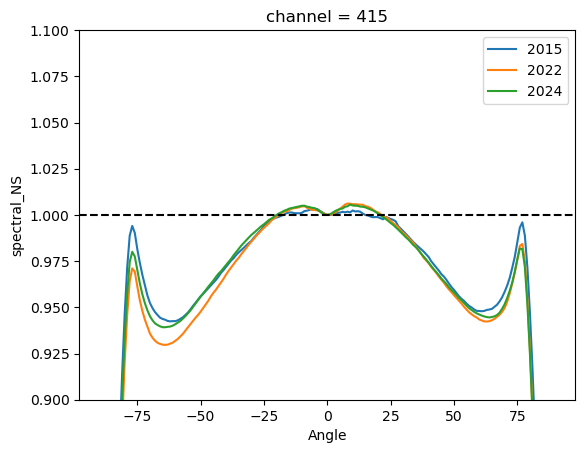

In [226]:
f,a = plt.subplots()
wl = 415
for cal in cals:
    dt = pd.to_datetime([c for c in cal.header.split('\n') if 'Test_date' in c][0].split('\t')[1]).year
    cal.spectral_NS.sel(channel = wl).plot(ax = a, label = dt)
a.axhline(1, color = 'black', ls = '--')
a.set_ylim(0.9,1.1)
a.legend()

# Compare to what Gary uses

In [ ]:
Gary

In [227]:
dssol = sol_parser.read_sol_to_xarray('tbl_mfrsr_20221103_D824_3126_660.sol')

(0.9, 1.1)

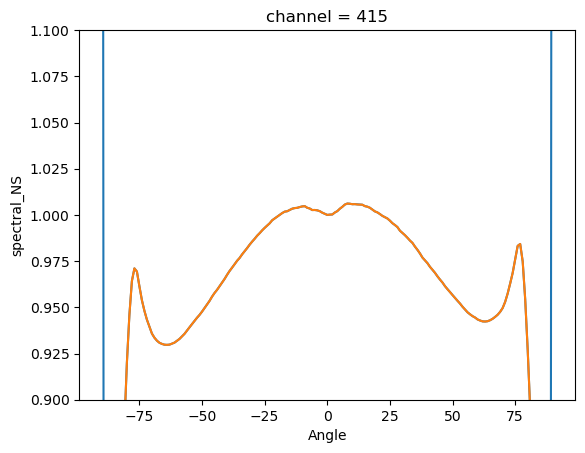

In [234]:
f,a = plt.subplots()
cal = cals[1]
# dssol.SN.sel(channel = 2).plot(ax = a)
a.plot(-dssol.angle, dssol.SN.sel(channel = 2))
wl = 415
cal.spectral_NS.sel(channel = wl).plot(ax = a, label = dt)
a.set_ylim(0.9,1.1)

# plot for testing

In [165]:

na = 500
nz = 500
coord_az = np.linspace(0,360, na)
coord_ze = np.linspace(0,90, nz)
# az, ze = np.meshgrid(coord_az, coord_ze)

In [166]:
dat = dspol.spectral.interp({'azimuth': coord_az, 'zenith': coord_ze})
# dat

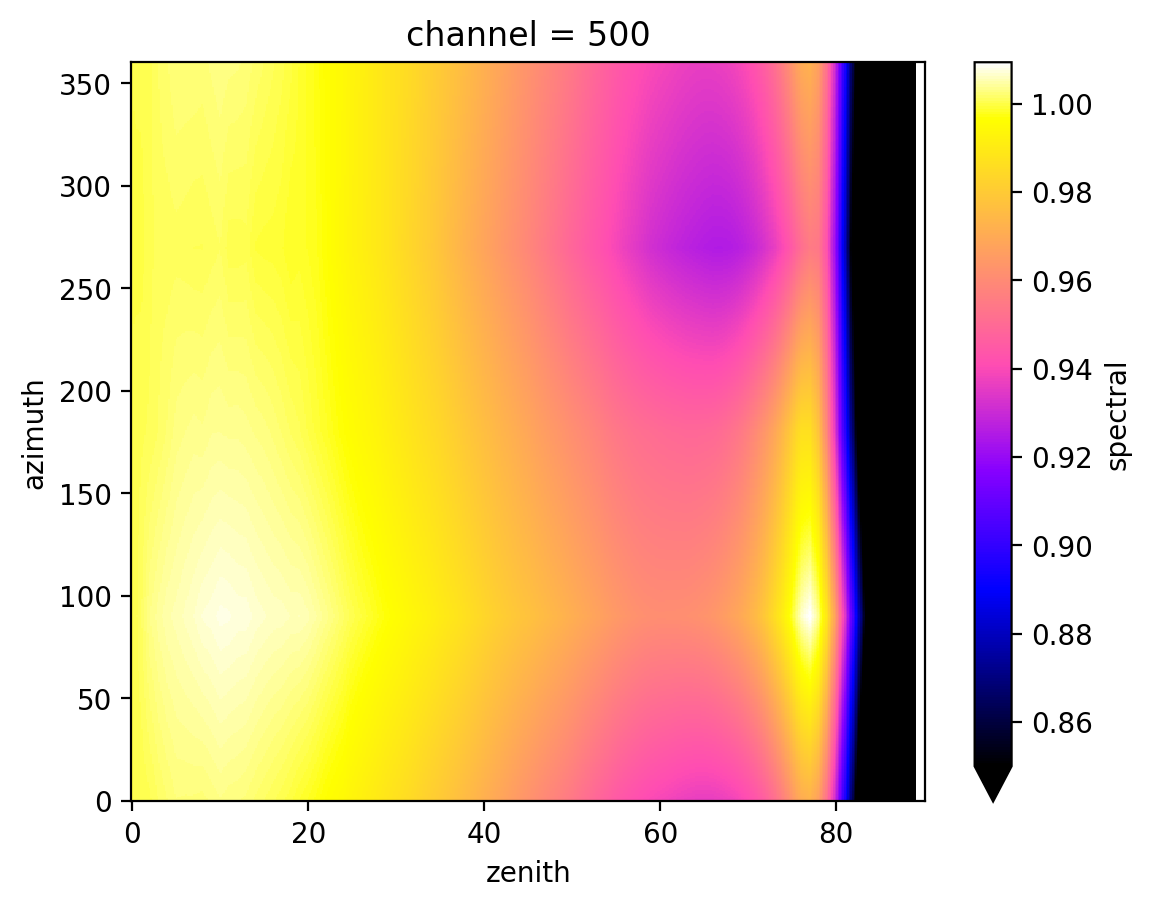

In [168]:
dat.sel(channel = wl).plot(cmap = plt.cm.gnuplot2, vmin = 0.85)#norm = 'log')